# Figure 3-7 + Supplementary Figure 1+2 Code
Contains code to produce figures present in Fig 3-7. 
#### Run Order
- Environment and Imports
- Config (paths, parameters)
- Load Data
- Process Data
- Cross condition decoding generalization (CCG) figures:
    - Figure 3: B
    - Figure 4: B
- CCG Class predictions:
    - Figure 3: C
    - Figure 4: C, F
- Linear SVM accuracy figures:
    - Figure 5: C, D
    - Figure 6: C, D
    - Figure 7: C, G
    - Supplementary Figure 2: F, H
- Save Figures and Tables

## Setup


#### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os
import notebook_setup
info = notebook_setup.setup()
# Environment & Imports Setup
import matplotlib as matplotlib
%matplotlib inline 

#code ocean step
use_code_ocean = False
if use_code_ocean:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import pandas as pd
import random
from datetime import datetime

print(f"matplotlib {matplotlib.__version__} | Seaborn {sns.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.set_option('mode.use_inf_as_na', False) # pd.set_option('future.no_silent_downcasting', True)
np.random.seed(1) #set seed for reproducibility 
random.seed(1)
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
here = info["repo_root"]
print(f" Here: {here}")
_plot_posthoc_src = os.path.join(here, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)
#custom function import
import custom_module_imports as cmi 
from preprocess_data import hyper_param_dict
from helper_functions import save_fig_in_main_fig_dir,  save_plot_record_as_csv_txt, make_folder
from ax_modifier_functions import add_spaces_linebreak_to_stage_ticks, set_ax_title_xlabel_ylabel, set_pointplot_edgecolor, set_labels
from sns_plotting_config import * #import dicts containing default plot params
from plot_posthoc_test.plot_stat_annotate import *
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
##Set/create save and load folder paths 
results_location = Path(here).parents[0] / "results"
data_location = Path(here).parents[0] / "data"
make_folder(results_location)
make_folder(data_location)
print(f"Saving results in {results_location}. Data location is {data_location}")
csv_folder_most_recent = results_location/ f"analysis_CSV_output/" #folders that analysis output goes to
make_folder(csv_folder_most_recent)

matplotlib 3.7.0 | Seaborn 0.12.1
Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
 Here: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results' already exists.
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data' already exists.
Saving results in c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results. Data location is c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output' already exists.


<Figure size 960x720 with 0 Axes>

#### Extract pre-built time-series and transform


In [3]:
#declare loc/names of files to read
trial_df_filename = data_location /  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)


In [4]:

stage_col = 'task_phase_vec'
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = cmi.pp.get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
unit_mean_tseries =  cmi.pp.get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['name', 'neuron_ID','geno_day', stage_col], numeric_col) 
subject_stage_info_df = cmi.pp.get_subject_stage_info_df(trial_tseries_df_norm) # get subj level dfs
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['unique_ID'].nunique()
subject_stage_info_df.sample()

,name,geno_day,task_phase_vec,unique_ID,num_enriched_units,num_units,trial_num,count_of_trials,over_5
174,7_6_HET_RS2,Het CLNZ,Early_IA_Error,"[7_6_HET_RS2-10, 7_6_HET_RS2-20, 7_6_HET_RS2-2...",12,107,"[2, 3, 5]",3,"[False, False, False]"


#### Centralize import of all time-series

In [202]:
run_record_loc = r'C:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\results\\figure_5_prep_mid_decoding figures_21_Jan_2026'
generalize_svm_record_file = f"Decoder- Out of Distribution - run version record.csv"
#collect info on current runs to read them into notebook
last_run_info = pd.read_csv(run_record_loc + '/' + generalize_svm_record_file)
last_run_info

,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations
0,0,21_Jan_2026,in_distribution,2026-01-21 10:16:07.362842,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000
1,1,21_Jan_2026,out_of_distribution,2026-01-21 10:16:07.362842,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000
2,2,21_Jan_2026,timebin_decoding,2026-01-21 10:16:07.362842,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000


In [203]:
# Map decoding types to their target variable names
decoding_type_to_var = {
    'in_distribution': 'decode_scores',
    'timebin_decoding': 'time_decode_scores',
    'out_of_distribution': 'decode_out_distrib',
    'out_of_distribution_single_stage': 'decode_out_distrib_single_stage',
}

# Get the latest run for each decoding type
last_run_info['run_end_time'] = pd.to_datetime(last_run_info['run_end_time'])
latest_runs = last_run_info.loc[last_run_info.groupby('decoding_type')['run_end_time'].idxmax()]

# Read parquets into a dictionary
decode_dfs = {}
for _, row in latest_runs.iterrows():
    decoding_type = row['decoding_type']
    filepath = row['run_output_filename']
    
    if decoding_type in decoding_type_to_var:
        var_name = decoding_type_to_var[decoding_type]
        decode_dfs[var_name] = pd.read_parquet(filepath).rename(columns={"mean_acc":"accuracy"})
        print(f"Loaded {decoding_type} from {row['run_end_time']} ({len(decode_dfs[var_name])} rows) -> {var_name}")
    else:
        print(f"Warning: Unknown decoding type '{decoding_type}', skipped")

# Unpack to standalone variables for convenience
decode_scores = decode_dfs.get('decode_scores')
time_decode_scores = decode_dfs.get('time_decode_scores')
decode_out_distrib = decode_dfs.get('decode_out_distrib')
decode_out_distrib_single_stage = decode_dfs.get('decode_out_distrib_single_stage')

print(f"Loaded: {list(decode_dfs.keys())}")

Loaded in_distribution from 2026-01-21 10:16:07.362842 (960000 rows) -> decode_scores
Loaded out_of_distribution from 2026-01-21 10:16:07.362842 (120000 rows) -> decode_out_distrib
Loaded timebin_decoding from 2026-01-21 10:16:07.362842 (1440000 rows) -> time_decode_scores
Loaded: ['decode_scores', 'decode_out_distrib', 'time_decode_scores']


In [204]:
latest_runs

,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations
0,0,21_Jan_2026,in_distribution,2026-01-21 10:16:07.362842,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000
1,1,21_Jan_2026,out_of_distribution,2026-01-21 10:16:07.362842,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000
2,2,21_Jan_2026,timebin_decoding,2026-01-21 10:16:07.362842,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000


In [ ]:

latest_runs.run_dataset_used.unique()


array(['c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet'],
      dtype=object)

In [155]:
# #### read location of decoding csv from readout
# decoding_filename = "Decode enrich_unit 1000 pseudopop post_outcome_activity 31_May_2025.parquet"
# decode_scores = pd.read_parquet(data_location / decoding_filename)
# #
# time_decoding_filename = "Timebin Decoding- 1000_bootstrap post_outcome_activity 31_May_2025.parquet"
# time_decode_scores = pd.read_parquet(data_location / time_decoding_filename)

# CCG_filename = "Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 31_May_2025.parquet"
# decode_out_distrib = pd.read_parquet(data_location / CCG_filename)

#### Load and extract decoding CSV


In [156]:

pop_mean_decoding = decode_scores.groupby(by = ['geno_day', 'enriched_group', 'classes decoded', 'pseudopop_run_num'])['accuracy'].mean().reset_index() 
pop_mean_decoding[['class_0', 'class_1']]= pop_mean_decoding['classes decoded'].str.split('_v_',expand=True)
print(pop_mean_decoding.info())
pop_mean_decoding.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Data columns (total 7 columns):
 #   Column             Dtype   
---  ------             -----   
 0   geno_day           category
 1   enriched_group     category
 2   classes decoded    category
 3   pseudopop_run_num  int64   
 4   accuracy           float64 
 5   class_0            object  
 6   class_1            object  
dtypes: category(3), float64(1), int64(1), object(2)
memory usage: 80.1+ MB
None


,geno_day,enriched_group,classes decoded,pseudopop_run_num,accuracy,class_0,class_1
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.99250,Early_IA_Correct,Early_IA_Error
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.97375,Early_IA_Correct,Early_IA_Error
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.99125,Early_IA_Correct,Early_IA_Error
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.99375,Early_IA_Correct,Early_IA_Error
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.99375,Early_IA_Correct,Early_IA_Error


#### Load and extract time-bin dependent decoding CSV


In [157]:

time_decode_scores = time_decode_scores.rename({"Phase1": "class_0", "Phase2": "class_1"}, axis = 1)
time_decode_scores['bin_name'] = time_decode_scores.bin_start_str.str.cat( time_decode_scores.bin_end_str, sep = ' to ')
time_decode_scores.head()

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,accuracy,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded,bin_name
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[0, 11]",0,11,-3.0s,0.99125,-0.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,-3.0s to -0.0s
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[12, 23]",12,23,0.0s,0.97875,3.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,0.0s to 3.0s
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[24, 35]",24,35,3.0s,0.99625,6.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,3.0s to 6.0s
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[36, 47]",36,47,6.0s,0.99875,9.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,6.0s to 9.0s
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[48, 59]",48,59,9.0s,0.99500,12.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,9.0s to 12.0s


## Figure 3 & 4- Cross-condition generalization 

In [158]:
def plot_out_of_distribution_SVM_result(decode_out_distrib, decoder_comparison, decoding_col, ax_plot):
    plot_df =  decode_out_distrib.loc[(decode_out_distrib[decoding_col] == decoder_comparison),:]
    errorbar_pi = 75
    plot_params = {'data':plot_df, 'dodge': 0.4, 'x': 'enriched_group', 'y':'accuracy','order':phase_list_IA_RS_chrono,'errorbar': ('pi', errorbar_pi), **geno_color_dict_no_errorbar}
    ## ax level changes
    s = sns.pointplot(ax = ax_plot,linestyles = 'none', **plot_params)#make cosine sim plot itself
    fig_name = f' Train: {plot_df.train_on.unique()[0]} \n Test: {plot_df.test_on.unique()[0]} \n SVM Accuracy (PI: {errorbar_pi}) ({plot_df.pseudopop_run_num.nunique()} run avg.)'
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': [0, 1.025],'xlabel': None, 'ylabel': 'Mean SVM accuracy', 'legend_false': True})#adjust plot information
    
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, preset_comparison_list, test_name = 'cohen_d', detect_error_bar = False)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True, tight_offset = 0.02) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    
    ax_add_stage_names_and_outline_points(ax_plot)
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)#add 0 second line
    return posthoc_df

In [159]:
decode_out_distrib.head()

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,cosine_c0_train_v_c1_test,...,class_1_test,regularization,date_run,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on
0,0.662500,94.0,86.0,0.404219,0.258281,0.241719,0.095781,0.535214,0.554371,0.561841,...,Early_RS_Error,l2,2026-01-19 10:30:32.550132,0.75,4,0.25,2026-01-19 11:37:10.491631,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
1,0.672031,94.0,78.0,0.418125,0.253906,0.246094,0.081875,0.540913,0.554371,0.404407,...,Early_RS_Correct,l2,2026-01-19 10:30:32.578713,0.75,4,0.25,2026-01-19 11:37:10.491631,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct
2,0.537656,94.0,91.0,0.240781,0.296875,0.203125,0.259219,0.554371,0.535214,0.561841,...,Early_RS_Error,l2,2026-01-19 10:30:32.606722,0.75,4,0.25,2026-01-19 11:37:10.491631,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error
3,0.514531,94.0,67.0,0.333125,0.181406,0.318594,0.166875,0.704203,0.535214,0.404407,...,Early_IA_Error,l2,2026-01-19 10:30:32.634189,0.75,4,0.25,2026-01-19 11:37:10.491631,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error
4,0.660312,33.0,31.0,0.306250,0.354063,0.145937,0.193750,0.510919,0.516374,0.630588,...,Early_RS_Error,l2,2026-01-19 10:30:32.670912,0.75,4,0.25,2026-01-19 11:37:10.491631,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error


In [160]:

decode_out_distrib['train_on'] = decode_out_distrib['class_0_train'].str.cat(decode_out_distrib['class_1_train'], sep = "_").str.replace('_', ' ')
decode_out_distrib['test_on'] = decode_out_distrib['class_0_test'].str.cat(decode_out_distrib['class_1_test'], sep = "_").str.replace('_', ' ')
decode_out_distrib['classes decoded'] = decode_out_distrib['train_on'].str.cat(decode_out_distrib['test_on'], sep = " v ")
decode_out_distrib['classes decoded'] = decode_out_distrib['classes decoded'].str.replace('_', ' ')
decode_out_distrib['total'] = decode_out_distrib['true_pos'] + decode_out_distrib['false_neg'] + decode_out_distrib['false_pos'] + decode_out_distrib['true_neg']
decode_out_distrib.head()

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,cosine_c0_train_v_c1_test,...,date_run,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,classes decoded,total
0,0.662500,94.0,86.0,0.404219,0.258281,0.241719,0.095781,0.535214,0.554371,0.561841,...,2026-01-19 10:30:32.550132,0.75,4,0.25,2026-01-19 11:37:10.491631,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.672031,94.0,78.0,0.418125,0.253906,0.246094,0.081875,0.540913,0.554371,0.404407,...,2026-01-19 10:30:32.578713,0.75,4,0.25,2026-01-19 11:37:10.491631,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Error Early RS Error,Early IA Correct Early RS Correct,Early IA Error Early RS Error v Early IA Corre...,1.0
2,0.537656,94.0,91.0,0.240781,0.296875,0.203125,0.259219,0.554371,0.535214,0.561841,...,2026-01-19 10:30:32.606722,0.75,4,0.25,2026-01-19 11:37:10.491631,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early IA Error,Early RS Correct Early RS Error,Early IA Correct Early IA Error v Early RS Cor...,1.0
3,0.514531,94.0,67.0,0.333125,0.181406,0.318594,0.166875,0.704203,0.535214,0.404407,...,2026-01-19 10:30:32.634189,0.75,4,0.25,2026-01-19 11:37:10.491631,c:\Users\13car\Dropbox\local_github_repos_pers...,Early RS Correct Early RS Error,Early IA Correct Early IA Error,Early RS Correct Early RS Error v Early IA Cor...,1.0
4,0.660312,33.0,31.0,0.306250,0.354063,0.145937,0.193750,0.510919,0.516374,0.630588,...,2026-01-19 10:30:32.670912,0.75,4,0.25,2026-01-19 11:37:10.491631,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,Early IA Correct Early RS Correct v Early IA E...,1.0


#### Figure 3B - CCGP for models Trained on IA, Tested on RS

In [161]:
#function- ax level plot of CCGP
from ax_modifier_functions import add_xtick_color_boxes
def plot_cross_condition_generalization_performance(
    ax_plot,
    decode_out_distrib,
    decoding_col,
    decode_comp,
    enriched_group,
    ensembles_to_plot,
    posthoc_comparisons,
    marker_params,
    ylim:list = [0.2, 1.025],
    verbose_titles:list = ['train IA', 'test RS'],
    **kwargs):
    """    Plots cross-condition generalization SVM accuracy and performs post-hoc tests.
    Parameters:
    - decode_out_distrib: pd.DataFrame, decoding results
    - decoding_col: str, column name to compare with decode_comp
    - decode_comp: value to filter decoding_col on
    - enriched_group: str, column name used to group for plotting
    - ensembles_to_plot: list of group names to include in the plot
    - geno_color_dict_no_errorbar: dict, seaborn styling arguments like hue/colors
    - preset_comparison_list: list of tuples, preset comparisons for posthoc tests
    - ax_plot: matplotlib.axes.Axes, axis to plot on
    Returns:    - ax_plot with the plot drawn and significance bars added
    """
    ## plot info 
    plot_mask = (decode_out_distrib[decoding_col] == decode_comp) & (decode_out_distrib[enriched_group].isin(ensembles_to_plot))
    plot_df =  decode_out_distrib.loc[plot_mask,:]
    plot_params = {'data':plot_df, 'dodge': 0.5,'errwidth': 1.5, 'x': 'enriched_group', 'y':'accuracy','order':ensembles_to_plot, 'errorbar': ('pi', 75), **marker_params}
    s = sns.pointplot(ax = ax_plot,linestyles = 'none', **plot_params,**kwargs)#make cosine sim plot itself
    ## ax level changes
    train_data, test_data = verbose_titles#new- extract cleaner string title from train/test data
    fig_name = f" {train_data.replace('_', ' ') }\n {test_data.replace('_', ' ')}"
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': ylim, 'legend_false': False,
                                         'xlabel': f"Cell Ensemble", 'ylabel': 'Cross-condition Generalization'})#adjust plot information
    #posthoc difference detection
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, posthoc_comparisons, detect_error_bar = True,test_name = 'cohen_d')
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.03,offset_constant = 0.015) 
    #more ax tuning
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)#add 0 second line
    set_pointplot_edgecolor(ax_plot)
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    return posthoc_df

In [162]:
#create longer titles for figures + combine into dict for substitution into figures
verbose_dicts = { 'train_Early_IA_Correct_Early_IA_Error': ['Classify Correct vs. Error:', 'Train on IA trials, Test on RS trials'], 
                 'train_Early_IA_Correct_Early_RS_Correct':['Classify IA vs. RS:','Train on Correct trials, Test on Errors']}
#Set figure panel sizes
ccg_uniprop_figsize = (1.5, 2)
svm_panel_size = (1.3,1.9)
supp_svm_panel_size = (1.75,2)
ccg_confusion_figsize = (1.65,2)
ccgp_figsize = (2,2)
time_dep_panel_size = (1.75,1.75)

Saved 3_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 21_Jan_2026_ccgp_all_posthoc cohen d_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\3_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 21_Jan_2026_ccgp_posthoc_results_text_21_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3\21_Jan_2026' already exists.


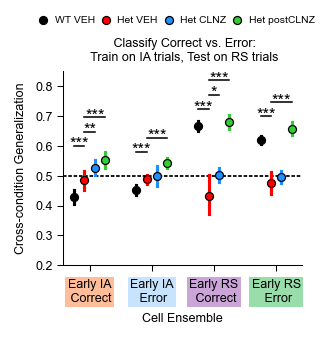

In [163]:
train_data = 'train_Early_IA_Correct_Early_IA_Error'
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
posthoc_df = plot_cross_condition_generalization_performance(ax_plot,
                                                             decode_out_distrib,
                                                             decoding_col = 'classes decoded',
                                                             decode_comp = 'Early IA Correct Early IA Error v Early RS Correct Early RS Error',
                                                             enriched_group = 'enriched_group',
                                                             ensembles_to_plot = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'],
                                                             posthoc_comparisons= preset_comparison_list, 
                                                             marker_params= geno_color_dict_no_errorbar,
                                                             ylim =[0.2, 0.85],   
                                                             verbose_titles= verbose_dicts[train_data],
                                                             scale = 1.)
add_xtick_color_boxes(ax_plot,['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'], stage_palette_dict)
hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None)
##save fig 
fig_name = f"CCGP- {verbose_dicts[train_data][1]}_Early stage ens_ {date_tag}"
save_plot_record_as_csv_txt(posthoc_df,"3",fig_name,csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=3, filetypes_to_save = ['pdf', 'png','svg'])

#### Figure 4B - CCGP for models trained on Correct (IA/RS) and tested on Error (IA/RS)

Saved 4_SVM generalize (early ens) train_correct_test_error accuracy_ccgp_all_posthoc cohen d_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_SVM generalize (early ens) train_correct_test_error accuracy_ccgp_posthoc_results_text_21_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\21_Jan_2026' already exists.


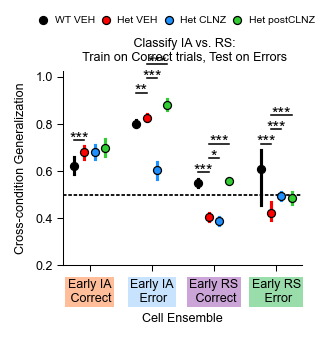

In [164]:
## figure params 
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
train_data = 'train_Early_IA_Correct_Early_RS_Correct'
posthoc_df = plot_cross_condition_generalization_performance(ax_plot,decode_out_distrib,
    decoding_col = 'classes decoded',
    decode_comp = 'Early IA Correct Early RS Correct v Early IA Error Early RS Error',
    enriched_group = 'enriched_group',
    ensembles_to_plot = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'],
    posthoc_comparisons= preset_comparison_list,
    marker_params= geno_color_dict_no_errorbar,
    verbose_titles= verbose_dicts[train_data],scale = 1.)
##ax modifiers
add_xtick_color_boxes(ax_plot, ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'], stage_palette_dict)
hand, labs =ax_plot.get_legend_handles_labels() 
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None, )
##save fig_posthoc 
fig_name = f"SVM generalize (early ens) train_correct_test_error accuracy"
save_plot_record_as_csv_txt(posthoc_df,"4",fig_name,csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=4, filetypes_to_save = ['png','svg'])

## Plot the specific breakdown of classes predicted by CCG models

In [165]:
#cols to keep
confusion_mat_cols = ['true_pos','false_neg', 'false_pos', 'true_neg']
class_list = ['class_0_train','class_1_train','class_0_test','class_1_test']
run_ID_cols = ['geno_day','accuracy','pseudopop_run_num']

df = decode_out_distrib.loc[:,['enriched_group']+run_ID_cols +confusion_mat_cols + ['total'] + class_list].rename({'enriched_group':'ensemble'},axis = 1)
# df[confusion_mat_cols] = df[confusion_mat_cols].astype(int) / df['total'].values[:, None]  # Normalize to proportions
df.tail()

df[class_list] = df[class_list].astype(str)
# 3. Build all new columns w. vectorized string operations
df = df.assign(
    train_on = 'train_' + df['class_0_train'] + '_x_' + df['class_1_train'],
    test_on  = 'test_'  + df['class_0_test']  + '_x_' + df['class_1_test'],
    Predict_class_1_train_x_Actual_class_1_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_1_test']),
    Predict_class_0_train_x_Actual_class_1_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_1_test']),
    Predict_class_1_train_x_Actual_class_0_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_0_test']),
    Predict_class_0_train_x_Actual_class_0_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_0_test'])
)
confusion_names = ['Predict_class_1_train_x_Actual_class_1_test',
                   'Predict_class_0_train_x_Actual_class_1_test',
                   'Predict_class_1_train_x_Actual_class_0_test', 
                   'Predict_class_0_train_x_Actual_class_0_test']
grouped = df[['ensemble', 'train_on','test_on'] +confusion_mat_cols + run_ID_cols+ confusion_names].set_index(['train_on', 'test_on','ensemble'])

df= grouped.reset_index().melt(value_vars = ['true_pos', 'false_neg', 'false_pos', 'true_neg'], id_vars = ['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy', 'pseudopop_run_num'] + confusion_names)
# 1. Define the mapping from your “variable” names to the Predict_… columns
col_map = {'true_pos':  'Predict_class_1_train_x_Actual_class_1_test','false_neg': 'Predict_class_0_train_x_Actual_class_1_test','false_pos': 'Predict_class_1_train_x_Actual_class_0_test','true_neg':  'Predict_class_0_train_x_Actual_class_0_test'}
df['var_column'] = df['variable'].map(col_map) #name of column containing var info
df['labels'] = df.apply(lambda row: row[row['var_column']],axis=1)
df[['predict', 'actual']] = df.labels.str.split("_x_", expand = True)
input_df = df[['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy','pseudopop_run_num','value','labels', 'predict', 'actual', 'var_column', 'variable']].set_index(("train_on")).copy()
input_df.loc[:,'actual'] = input_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
input_df['value'] = input_df['value']*2
input_df.sample()

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Early_IA_Correct,Het CLNZ,0.490469,9283,0.342187,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...,Predict_Early_RS_Correct,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg


In [166]:
input_df

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.662500,0,0.808437,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Early_IA_Correct,Het CLNZ,0.672031,0,0.836250,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Early RS Correct,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.537656,0,0.481563,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Error,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Early_IA_Correct,Het CLNZ,0.514531,0,0.666250,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Error,Early IA Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het VEH,0.660312,0,0.612500,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
...,...,...,...,...,...,...,...,...,...,...,...
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Late_RS,WT CLNZ,0.463594,9999,0.349062,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...,Predict_Early_RS_Correct,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Late_RS,WT VEH,0.577500,9999,0.381250,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct,Early IA Error,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Late_RS,WT VEH,0.556875,9999,0.161250,Predict_Early_IA_Error_x_Actual_Early_IA_Correct,Predict_Early_IA_Error,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg


In [167]:
def plot_ccg_confusion_single_proportion(ax,
                                         input_df,
                                         train,
                                         ens,
                                         prediction_class = "Predict_Early_RS_Correct",
                                         genos_to_plot = geno_order,
                                         errorbar = ('pi', 95),
                                         ylim=[0, 0.515],
                                         title_type = {'train_Early_IA_Correct_x_Early_RS_Correct':'Classification (IA vs. RS) of',
                                                       'train_Early_IA_Correct_x_Early_IA_Error': 'Classification (correct vs. error) of'},
                                         **kwargs):
    ''' started 6/25/25- To plot distributions of ccg''' 
    #modify df for better plot
    train_df = input_df.loc[train,:].reset_index()
    plot_df = train_df.loc[train_df.ensemble == ens,:].copy()
    plot_df.loc[:,'actual'] = plot_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
    #given you plot only one type, filter by type
    plot_df = plot_df.loc[plot_df.predict == prediction_class,:]
    plot_df['value'] = plot_df['value'] *100 #multiply by 100 to return percent
    stage_order = sorted(set(plot_df.loc[:,'actual']))
    plot_params = dict(data = plot_df,ax = ax,x = 'actual', y = 'value', dodge = 0.5, linestyles = 'none',order = stage_order,errorbar = errorbar, 
                       **{True:geno_order_w_WT_CLNZ_no_eb, False:geno_color_dict_no_errorbar}["WT CLNZ" in genos_to_plot])
    s = sns.pointplot(**plot_params)
    ###modify ax decorators
    set_pointplot_edgecolor(ax)
    ax_title = f"{title_type[train]}\n activity in {ens.replace('_', ' ')} ensemble"
    ylabel_options = {'train_Early_IA_Correct_x_Early_IA_Error': 'Correct',
                      'train_Early_IA_Correct_x_Early_RS_Correct':'RS'}
    set_labels(ax, label_dict = {'title':ax_title,
                                 'legend_false':True, 
                                 'xlabel':f"Test Data Stage",
                                 'ylim':ylim, 'ylabel': f"% Classified as {ylabel_options[train]}"})
    #run posthoc test 
    if "WT CLNZ" in plot_params['hue_order']: #NEW- alternate what comparison list to use based on if WT-CLNZ in hue_order or not
        print(f"switching posthoc comparison to include WT CLNZ")
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    # Draw canvas to ensure error bar coordinates are computed (fixes multi-subplot issue)
    ax.figure.canvas.draw()
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, s, comparisons, detect_error_bar = True,test_name = 'cohen_d')
    plot_sig_bars_w_comp_df_tight(ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.0175,offset_constant = 0.0085) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    #more ax tuning
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels())) 
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 100])
    return posthoc_df

#### Figure 3C: CCG model classifications of activity of Early RS Correct ensemble 

PathCollection indices: [3, 7, 11, 15]

=== bar_coords (error bar lines) ===
           child_x                        child_y  y_is_2_elem
0    [-0.25, 0.75]   [55.858253125, 22.824203125]         True
1   [-0.25, -0.25]               [53.0, 58.71875]         True
2     [0.75, 0.75]                 [21.0, 24.625]         True
3    [-0.08, 0.92]   [55.769153125, 69.514759375]         True
4   [-0.08, -0.08]      [50.53125000000001, 61.0]         True
5     [0.92, 0.92]            [50.6875, 85.03125]         True
6     [0.08, 1.08]    [61.776409375, 61.20020625]         True
7     [0.08, 0.08]             [58.375, 65.15625]         True
8     [1.08, 1.08]  [57.56250000000001, 64.65625]         True
9     [0.25, 1.25]   [89.133059375, 53.257328125]         True
10    [0.25, 0.25]            [87.03125, 91.0625]         True
11    [1.25, 1.25]           [48.34375, 57.96875]         True

=== hue_loc_df (point positions) ===
                                                      data_locs
hu

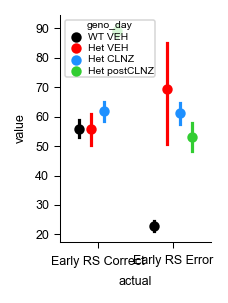

In [168]:
from matplotlib.collections import PathCollection as path_collection_type

# Create the plot
ensemble = "Early_RS_Correct"
fig, ax = plt.subplots(1,1, figsize=ccg_uniprop_figsize, layout='tight')

# Reproduce plotting code from the function
train = 'train_Early_IA_Correct_x_Early_IA_Error'
train_df = input_df.loc[train,:].reset_index()
plot_df = train_df.loc[train_df.ensemble == ensemble,:].copy()
plot_df.loc[:,'actual'] = plot_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
prediction_class = "Predict_Early_IA_Correct"
plot_df = plot_df.loc[plot_df.predict == prediction_class,:]
plot_df['value'] = plot_df['value'] * 100

stage_order = sorted(set(plot_df.loc[:,'actual']))
plot_params = dict(data=plot_df, ax=ax, x='actual', y='value', dodge=0.5, 
                   linestyles='none', order=stage_order, errorbar=('pi', 75),
                   **geno_color_dict_no_errorbar)
s = sns.pointplot(**plot_params)
ax.figure.canvas.draw()

# DEBUG: Inspect error bar detection
ax_childs = s.get_children()
ax_child_types = [type(x) for x in ax_childs]
ax_child_points_index = [count for count, x in enumerate(ax_child_types) if x is path_collection_type]
print(f"PathCollection indices: {ax_child_points_index}")

# Check what's in bar_coords
from plot_posthoc_test.plot_stat_annotate import return_ax_child_line_coor
bar_coords = return_ax_child_line_coor(ax_childs, ax_child_points_index)
bar_coords['y_is_nonnan'] = bar_coords.child_y.apply(lambda x: ~np.any(np.isnan(x)))
bar_coords['y_is_2_elem'] = bar_coords.child_y.apply(lambda x: x.size == 2)

print("\n=== bar_coords (error bar lines) ===")
print(bar_coords[['child_x', 'child_y', 'y_is_2_elem']].to_string())

# Check what coordinates posthoc_df expects to match
from plot_posthoc_test.plot_stat_annotate import get_hue_point_loc_df
hue_loc_df = get_hue_point_loc_df(ax, geno_order)
print("\n=== hue_loc_df (point positions) ===")
print(hue_loc_df)

In [169]:
# Debug: What Line2D objects exist?
lines = [x for x in ax.get_children() if isinstance(x, matplotlib.lines.Line2D)]
print(f"Total Line2D objects: {len(lines)}")

for i, line in enumerate(lines):
    xdata = line.get_xdata()
    ydata = line.get_ydata()
    print(f"Line {i}: x={np.round(xdata, 3)}, y={np.round(ydata, 3)}")

# Also check PathCollection (the actual points)
from matplotlib.collections import PathCollection
collections = [x for x in ax.get_children() if isinstance(x, PathCollection)]
print(f"\nTotal PathCollections: {len(collections)}")
for i, coll in enumerate(collections):
    offsets = coll.get_offsets()
    print(f"Collection {i}: offsets={offsets}")

Total Line2D objects: 12
Line 0: x=[-0.25  0.75], y=[55.858 22.824]
Line 1: x=[-0.25 -0.25], y=[53.    58.719]
Line 2: x=[0.75 0.75], y=[21.    24.625]
Line 3: x=[-0.083  0.917], y=[55.769 69.515]
Line 4: x=[-0.083 -0.083], y=[50.531 61.   ]
Line 5: x=[0.917 0.917], y=[50.688 85.031]
Line 6: x=[0.083 1.083], y=[61.776 61.2  ]
Line 7: x=[0.083 0.083], y=[58.375 65.156]
Line 8: x=[1.083 1.083], y=[57.563 64.656]
Line 9: x=[0.25 1.25], y=[89.133 53.257]
Line 10: x=[0.25 0.25], y=[87.031 91.062]
Line 11: x=[1.25 1.25], y=[48.344 57.969]

Total PathCollections: 4
Collection 0: offsets=[[-0.25 55.858253125]
 [0.75 22.824203125]]
Collection 1: offsets=[[-0.08333333333333334 55.769153125]
 [0.9166666666666666 69.514759375]]
Collection 2: offsets=[[0.08333333333333331 61.776409375]
 [1.0833333333333333 61.20020625]]
Collection 3: offsets=[[0.25 89.133059375]
 [1.25 53.257328125]]


In [170]:
# Check the actual data being plotted
print("=== Data check ===")
print(f"plot_df['value'] stats: min={plot_df['value'].min()}, max={plot_df['value'].max()}, mean={plot_df['value'].mean()}")
print(f"\nFirst 5 rows:\n{plot_df[['actual', 'value', 'geno_day']].head()}")

# Check what the axes are showing
print(f"\n=== Axes limits ===")
print(f"ylim: {ax.get_ylim()}")
print(f"xlim: {ax.get_xlim()}")

# Check seaborn version
import seaborn as sns
print(f"\nSeaborn version: {sns.__version__}")

=== Data check ===
plot_df['value'] stats: min=16.875, max=95.78125, mean=59.0319978125

First 5 rows:
                actual     value      geno_day
300015  Early RS Error  62.25000      Het CLNZ
300016  Early RS Error  80.03125       Het VEH
300017  Early RS Error  53.65625  Het postCLNZ
300018  Early RS Error  56.71875       WT CLNZ
300019  Early RS Error  24.31250        WT VEH

=== Axes limits ===
ylim: (17.496875, 94.565625)
xlim: (-0.5, 1.5)

Seaborn version: 0.12.1


In [171]:
# Trace the data pipeline
train = 'train_Early_IA_Correct_x_Early_IA_Error'
ensemble = "Early_RS_Correct"
prediction_class = "Predict_Early_IA_Correct"

print("=== Step 1: input_df at train index ===")
train_df = input_df.loc[train,:].reset_index()
print(f"Shape: {train_df.shape}")
print(f"value stats: min={train_df['value'].min()}, max={train_df['value'].max()}")
print(f"Unique ensembles: {train_df['ensemble'].unique()}")

print("\n=== Step 2: Filter by ensemble ===")
ens_df = train_df.loc[train_df.ensemble == ensemble,:]
print(f"Shape after ensemble filter: {ens_df.shape}")
print(f"value stats: min={ens_df['value'].min()}, max={ens_df['value'].max()}")

print("\n=== Step 3: Filter by prediction_class ===")
pred_df = ens_df.loc[ens_df.predict == prediction_class,:]
print(f"Shape after predict filter: {pred_df.shape}")
print(f"value stats: min={pred_df['value'].min()}, max={pred_df['value'].max()}")
print(f"\nSample rows:\n{pred_df[['ensemble', 'predict', 'actual', 'value']].head(10)}")

=== Step 1: input_df at train index ===
Shape: (1200000, 12)
value stats: min=0.0, max=1.0
Unique ensembles: ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']

=== Step 2: Filter by ensemble ===
Shape after ensemble filter: (200000, 12)
value stats: min=0.0421875, max=0.9578125000000001

=== Step 3: Filter by prediction_class ===
Shape after predict filter: (100000, 12)
value stats: min=0.16875, max=0.9578125000000001

Sample rows:
                ensemble                   predict          actual     value
300015  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.622500
300016  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.800312
300017  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.536563
300018  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.567188
300019  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.243125
300045  Early_RS_Correct  Predict_Early_IA_Correct  Early

In [172]:
# Check the source data
print("=== decode_out_distrib confusion matrix values ===")
print(decode_out_distrib[confusion_mat_cols].describe())

print("\n=== After normalization ===")
df_test = decode_out_distrib.loc[:,['enriched_group']+run_ID_cols +confusion_mat_cols + ['total'] + class_list].copy()
print(f"Before astype(int): {df_test[confusion_mat_cols].dtypes}")
print(f"Sample values before division:\n{df_test[confusion_mat_cols].head()}")
print(f"Sample total values: {df_test['total'].head().tolist()}")

# The potential issue - check what astype(int) does
df_test[confusion_mat_cols] = df_test[confusion_mat_cols].astype(int)
print(f"\nAfter astype(int):\n{df_test[confusion_mat_cols].head()}")

df_test[confusion_mat_cols] = df_test[confusion_mat_cols] / df_test['total'].values[:, None]
print(f"\nAfter division by total:\n{df_test[confusion_mat_cols].head()}")

=== decode_out_distrib confusion matrix values ===
           true_pos     false_neg     false_pos      true_neg
count  1.200000e+06  1.200000e+06  1.200000e+06  1.200000e+06
mean   2.673263e-01  2.326737e-01  2.163407e-01  2.836593e-01
std    1.133851e-01  1.133851e-01  1.069921e-01  1.069921e-01
min    0.000000e+00  1.250000e-03  0.000000e+00  1.828125e-02
25%    1.915625e-01  1.445312e-01  1.410937e-01  2.042188e-01
50%    2.775000e-01  2.225000e-01  2.206250e-01  2.793750e-01
75%    3.554688e-01  3.084375e-01  2.957812e-01  3.589062e-01
max    4.987500e-01  5.000000e-01  4.817188e-01  5.000000e-01

=== After normalization ===
Before astype(int): true_pos     float64
false_neg    float64
false_pos    float64
true_neg     float64
dtype: object
Sample values before division:
   true_pos  false_neg  false_pos  true_neg
0  0.404219   0.095781   0.241719  0.258281
1  0.418125   0.081875   0.246094  0.253906
2  0.240781   0.259219   0.203125  0.296875
3  0.333125   0.166875   0.318594  0.

Saved 3_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\3_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d text_21_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3\21_Jan_2026' already exists.


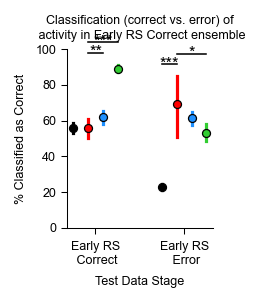

In [173]:
##Figure 3- TRAIN IA
ensemble = "Early_RS_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'tight')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                                  train = 'train_Early_IA_Correct_x_Early_IA_Error',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order,
                                                  prediction_class= "Predict_Early_IA_Correct",
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, None],)
##savefig 
fig_num = 3
fig_name = f"CCG single class pred- Train IA test RS - {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None, csv_suffix= "predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

In [174]:
posthoc_df

,category_compared_within,group_1,group_2,group_1_n,group_2_n,group_1_mean,group_1_sem,group_2_mean,group_2_sem,test_name,...,g_2_child_x,g_2_child_y,max_group_loc_val,numeric_var,hue_var,x_category_var,hue_is_x_axis,date_tag,fig_name,fig_num
0,Early RS Error,WT VEH,Het VEH,"(10000,)","(10000,)",22.7853,1.0278,69.9363,11.2727,robust_cohen_d,...,"[0.92, 0.92]","[50.6875, 85.03125]",85.03125,value,geno_day,actual,False,21_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3
1,Early RS Error,Het VEH,Het CLNZ,"(10000,)","(10000,)",69.9363,11.2727,61.2837,1.9436,robust_cohen_d,...,"[1.08, 1.08]","[57.56250000000001, 64.65625]",85.03125,value,geno_day,actual,False,21_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3
2,Early RS Error,Het VEH,Het postCLNZ,"(10000,)","(10000,)",69.9363,11.2727,53.3356,2.7126,robust_cohen_d,...,"[1.25, 1.25]","[48.34375, 57.96875]",85.03125,value,geno_day,actual,False,21_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3
3,Early RS Correct,WT VEH,Het VEH,"(10000,)","(10000,)",55.8954,1.5628,55.7728,2.9943,robust_cohen_d,...,"[-0.08, -0.08]","[50.53125000000001, 61.0]",61.00000,value,geno_day,actual,False,21_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3
4,Early RS Correct,Het VEH,Het CLNZ,"(10000,)","(10000,)",55.7728,2.9943,61.8111,1.9133,robust_cohen_d,...,"[0.08, 0.08]","[58.375, 65.15625]",65.15625,value,geno_day,actual,False,21_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3
5,Early RS Correct,Het VEH,Het postCLNZ,"(10000,)","(10000,)",55.7728,2.9943,89.2375,1.1170,robust_cohen_d,...,"[0.25, 0.25]","[87.03125, 91.0625]",91.06250,value,geno_day,actual,False,21_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3


#### Figure 4C: % of samples classified as RS, for activity from Early IA Correct ensemble

Saved 4_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d text_21_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\21_Jan_2026' already exists.


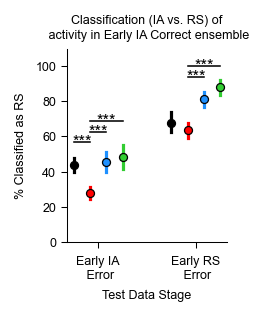

In [175]:
ensemble = "Early_IA_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                       train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                       ens= ensemble,
                                       genos_to_plot = geno_order,
                                       prediction_class = "Predict_Early_RS_Correct",
                                       errorbar = ('pi', 75), ylim=[0, 110])
##savefig 
fig_num = 4
fig_name = f"CCG single class pred- Train Correct test Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None,
                        csv_suffix="predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### Figure 4F: % of samples classified as RS, for activity from Early RS Error ensemble

Saved 4_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d text_21_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\21_Jan_2026' already exists.


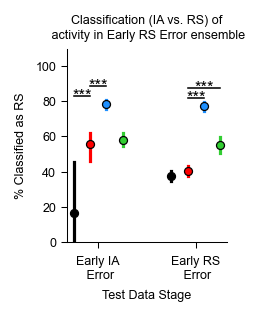

In [176]:
ensemble = "Early_RS_Error"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax,input_df,
                                                  train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order ,
                                                  prediction_class= "Predict_Early_RS_Correct",
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, 110],)
##savefig 
fig_num = 4
fig_name = f"CCG single class pred- Train Correct test Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None, csv_suffix="predict_posthoc cohen d",txt_suffix="predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### supplement uniproportion CCG classes

switching posthoc comparison to include WT CLNZ
Saved 2_s_supp_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d text_21_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\21_Jan_2026' already exists.


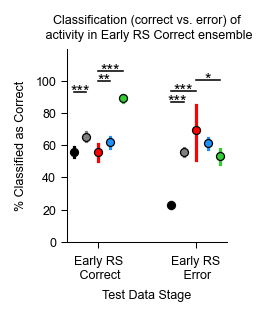

In [177]:
## SUPP Figure 3- TRAIN IA
ensemble = "Early_RS_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                       train = 'train_Early_IA_Correct_x_Early_IA_Error',
                                       ens= ensemble,
                                       genos_to_plot = geno_order_w_WT_CLNZ,
                                       prediction_class= "Predict_Early_IA_Correct",
                                       errorbar = ('pi', 75), ylim=[0, 120],)
##savefig 
fig_num = 3
fig_name = f"supp_CCG single class pred- Train IA test RS - {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"2_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix=f"supp_predict_posthoc cohen d",txt_suffix=f"supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f"s_2", filetypes_to_save = ['png','svg'])

switching posthoc comparison to include WT CLNZ
Saved 2_s_supp_CCG 1_class pred-Train_Correct_Test_Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_CCG 1_class pred-Train_Correct_Test_Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d text_21_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\21_Jan_2026' already exists.


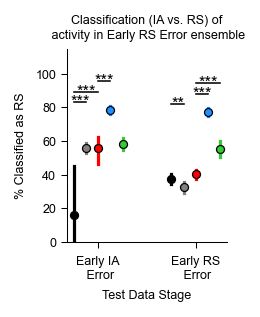

In [178]:
#SUPP FIGURE 4
ensemble = "Early_RS_Error"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                                  train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order_w_WT_CLNZ,
                                                  prediction_class= "Predict_Early_RS_Correct",
                                                  errorbar = ('pi', 75),ylim=[0, 115])
##savefig 
fig_num = 4
fig_name = f"supp_CCG 1_class pred-Train_Correct_Test_Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"2_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix="supp_predict_posthoc cohen d",txt_suffix="supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f's_2', filetypes_to_save = ['png','svg'])

switching posthoc comparison to include WT CLNZ
Saved 2_s_supp_CCG 1_class pred-Train_Correct_Test_Error-Early_IA_Correct ensemble_supp_predict_posthoc cohen d_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_CCG 1_class pred-Train_Correct_Test_Error-Early_IA_Correct ensemble_supp_predict_posthoc cohen d text_21_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\21_Jan_2026' already exists.


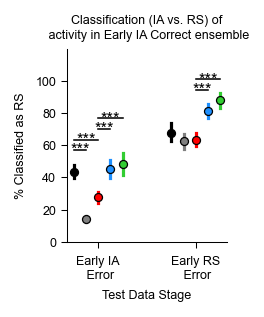

In [179]:
#FIGURE 4- IA Correct
ensemble = "Early_IA_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                       train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                       ens= ensemble,
                                       genos_to_plot = geno_order_w_WT_CLNZ, #specify if including WT CLNZ
                                       prediction_class= "Predict_Early_RS_Correct",
                                       errorbar = ('pi', 75), ylim=[0, 120])
##savefig 
fig_num = 4
fig_name = f"supp_CCG 1_class pred-Train_Correct_Test_Error-{ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"2_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix="supp_predict_posthoc cohen d",txt_suffix="supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f's_2', filetypes_to_save = ['png','svg'])

## Linear SVM Plots (Figures: 5-7 + S2)

In [180]:
def plot_decode_accuracy_ensemble_subset(pop_mean_decoding,
                                         decoding_col, 
                                         decoder_comparison, 
                                         ensemble_col,
                                         ax_plot,
                                         ensemble_subset=None, 
                                         ylim = [0.8, 1.05],
                                         plot_config = geno_color_dict_no_errorbar,
                                        **kwargs):
    ''' TO- plot 1 panel of SVM accuracy for 1 class decoding comparison, for all ensemble groups ued for decoding. inputs: plot config- usually contains geno_color_dict/ describes default paleete info, etc ''' 
    verbose_decoded_pairs = ['IA activity as Early IA vs Early RS', 'Correct activity as Early IA vs Early RS', 'IA activity as Early IA vs Late IA','Error activity as Early IA vs Early RS',
    'RS activity as Correct vs Error', 'RS activity as Early RS vs Late', 'activity as Late IA vs Early RS Correct', 'Late activity as Late IA vs Late RS']
    verbose_titles = {pair:verb  for verb, pair in zip(verbose_decoded_pairs,pop_mean_decoding['classes decoded'].unique().tolist())}
    verbose_titles
    if ensemble_subset == None:
        ensemble_subset= pop_mean_decoding[ensemble_col].unique()
    plot_df =  pop_mean_decoding.loc[(pop_mean_decoding[decoding_col] == decoder_comparison)&(pop_mean_decoding[ensemble_col].isin(ensemble_subset)) ,:]
    plot_params = {'data':plot_df, 'dodge': 0.35, 'markers': 'o',
                   'x': 'enriched_group', 'y':'accuracy', 'order':[x for x in phase_list_IA_RS_chrono if x in ensemble_subset ],
                   'errorbar': ('pi', 75), 'errwidth': 1.25, **plot_config}
    sc = sns.pointplot(ax = ax_plot, linestyles = 'none', **plot_params)#make cosine sim plot itself
    ## ax level changes
    verbose_decode = verbose_titles[decoder_comparison].replace("as", "as:\n").replace('_', ' ')
    set_pointplot_edgecolor(sc, edge_color = 'black', linewidth = marker_edge_width)
    set_ax_title_xlabel_ylabel(ax_plot, {'title':f"Classify {verbose_decode}", 'ylim': ylim,
                                         'xlabel': "Cell Ensemble", 'ylabel': 'Mean accuracy', 'legend_false':False})#adjust plot information
    if "WT CLNZ" in plot_params['hue_order']:#Switch comparison list to use, if WT-CLNZ in hue_order or not
        print(f"switching posthoc comparison to include WT CLNZ")
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, comparisons, test_name = 'cohen_d',detect_error_bar=True)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True,tight_offset = 0.04,offset_constant = 0.01) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    ##format ax 
    # Draw canvas to ensure tick labels are computed (fixes multi-subplot timing issue)
    ax_plot.figure.canvas.draw()
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    add_xtick_color_boxes(ax_plot, ensemble_subset, stage_palette_dict)
    return posthoc_df

def plot_save_ensemble_svm_accuracy(decoding_df,
                                    decoder_comparison:str,
                                    ensemble_subset:list= [],
                                    decoding_col:str = 'classes decoded', 
                                    figsize =(1.65,2), 
                                    fig_layout = 'tight',
                                    bbox_to_anchor=(0.7, .975),
                                    ylim = [0.90,1.015],
                                    fig_name = None,
                                    fig_folder=5,
                                    figure_prefix= "",
                                    add_legend = False,
                                    **kwargs):
        
    fig, ax = plt.subplots(1,1, figsize =figsize, layout = fig_layout)
    posthoc_df = plot_decode_accuracy_ensemble_subset(decoding_df, decoding_col, 
                                                      decoder_comparison, 'enriched_group',
                                                      ax_plot = ax,
                                                      ensemble_subset= ensemble_subset,
                                                      ylim = ylim,
                                                      **kwargs)
    #fix,tune axes
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 1.0])
    if add_legend:
        hand, labs =ax.get_legend_handles_labels() 
        fig.legend(hand, labs, bbox_to_anchor=(0.55, .975),loc = 'lower center', ncols = 4, frameon = False, title =None, **{
            'labelspacing': 0.0, 'markerscale': 1, 'borderpad': 0.0, 'columnspacing': 0.0, 'handletextpad': 0.0})
    #save figs 
    if fig_name is None:
        fig_name = f"SVM classifier accuracy {decoder_comparison} by ensemble"
    fig_name =  "_".join([figure_prefix,fig_name])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_folder, filetypes_to_save = ['png', 'svg'])
    posthoc_df['plot_name'] = fig_name
    save_plot_record_as_csv_txt(posthoc_df,
                                f"{fig_folder}",
                                fig_name,
                                csv_folder_most_recent, None,
                                csv_suffix="posthoc decode acc cohen D",txt_suffix="posthoc_text")
    return fig, ax,posthoc_df 


#### Figure 5C: SVM accuracy classifying Errors as Early IA vs Early RS, using Early RS Error or Early IA Error Ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5\21_Jan_2026' already exists.
Saved 5_5C_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc decode acc cohen D_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\5_5C_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc_text_21_Jan_2026.txt


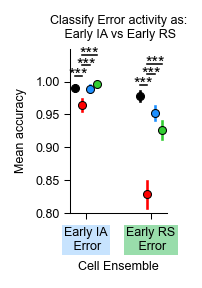

In [181]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Error_v_Early_RS_Error',
ensemble_subset = ['Early_IA_Error', 'Early_RS_Error'],ylim = [0.80,1.05], figsize = (1.25,1.90),fig_folder=5,  figure_prefix= "5C" )

#### Figure 5D: Time-based classification of Early IA Error vs Early RS Error, using Early RS Error ensemble data

In [182]:
def plot_ensemble_value_at_timebin(
    ax_plot, 
    timebin_values,
    ensemble,
    y_val,
    **kwargs):
    ''' Plot  time-bin bootstrapped metric for a given ensemble, for a given pair of classes to compare'''  

    plot_df = timebin_values.loc[timebin_values.enriched_group == ensemble,:].dropna()
    plot_df['bin_name'] = plot_df['bin_name'].str.replace(".0s to ", "-").str.replace(".0s", "").str.replace("--", "-")#rename bin
    plot_params = {'data': plot_df,  'x': 'bin_name', 'y' : y_val, 'errorbar': ('pi', 75), 'errwidth': 1.25, 'order': plot_df['bin_name'].unique(),
                  **kwargs, **geno_color_dict_no_errorbar}
    sc = sns.pointplot(ax = ax_plot, **plot_params,  )#make cosine sim plot itself
    set_pointplot_edgecolor(sc, edge_color = 'black', linewidth = marker_edge_width)    # ax_plot.legend_.remove()
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, preset_comparison_list, test_name = 'cohen_d',detect_error_bar = True)
    return posthoc_df

def plot_save_time_dep_decoding(
    decoding_df,
    decoding_col,
    decoding_metric = 'mean_acc',
    decoder_comparison = None,
    ensemble = None,
    ylim = [0.825,1.04],
    figsize = (1.75,1.75),
    fig_num=5,
    figure_prefix = "5D",
    use_verbose_title = True):
    ''' main script to plot time-dependent accuracy and save values ''' 
    verbose_decoded_pairs = ['IA activity as Early IA vs Early RS', 'Correct activity as Early IA vs Early RS', 'IA activity as Early IA vs Late IA','Error activity as Early IA vs Early RS',
    'RS activity as Correct vs Error', 'RS activity as Early RS vs Late', 'activity as Late IA vs Early RS Correct', 'Late activity as Late IA vs Late RS']
    verbose_titles = {pair:verb  for verb, pair in zip(verbose_decoded_pairs,pop_mean_decoding['classes decoded'].unique().tolist())}
    verbose_titles
    fig, ax_plot = plt.subplots(1, 1, figsize = figsize, layout = 'constrained')
    
    time_decode_classes = decoding_df.loc[decoding_df[decoding_col] == decoder_comparison,:]
    posthoc_df = plot_ensemble_value_at_timebin(ax_plot, time_decode_classes, ensemble, decoding_metric, dodge = True)
    
    #for plotting titles
    decoder_comparison_clean = decoder_comparison.replace('_', ' ')
    ensemble_clean = ensemble.replace('_', ' ')
    if use_verbose_title:
        ax_title = f'{ensemble_clean} ensemble:\nClassify {verbose_titles[decoder_comparison]}'
    else:
        ax_title = f'{ensemble_clean} ensemble:\n Decoding {decoder_comparison_clean}'
    set_ax_title_xlabel_ylabel(ax_plot, {'title':ax_title, 'legend_false':True,'xlabel': f"Decoded time window (s)", 
    'xtick_rotation':  {'rotation':30}, 'ylabel': 'Decoding Accuracy'})
    ax_plot.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.2f}"))
    
    ##savefig
    fig_name = "_".join([figure_prefix, f'{ensemble_clean} ensemble time-based classification of {decoder_comparison_clean}'])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=stage_to_fig[(decoder_comparison,ensemble)],  filetypes_to_save = ['png', 'svg'])
    #new- save posthoc, CSV
    posthoc_df['plot_name'] = ax_title
    save_plot_record_as_csv_txt(posthoc_df,
                                f"{fig_num}",
                                fig_name,
                                csv_folder_most_recent, None,
                                csv_suffix="posthoc acc cohen D",txt_suffix="posthoc_text")
    return fig, ax_plot,posthoc_df 

#### Supplementary Figure 2F: SVM accuracy classifying Errors as Early IA vs Early RS, using Early RS Error or Early IA Error Ensemble data (showing WT CLNZ)

switching posthoc comparison to include WT CLNZ
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\21_Jan_2026' already exists.
Saved s_2_S2_F_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc decode acc cohen D_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\s_2_S2_F_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc_text_21_Jan_2026.txt


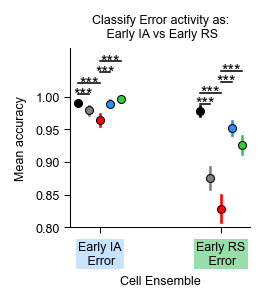

In [183]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Error_v_Early_RS_Error',
 ensemble_subset = ['Early_IA_Error', 'Early_RS_Error'], ylim = [0.82,1.075], figsize = supp_svm_panel_size,
 figure_prefix = "S2_F", fig_folder= 's_2', plot_config = geno_order_w_WT_CLNZ_no_eb)

#### Figure 6C: Early IA/RS Correct - SVM accuracy for Early RS Error Ensemble

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\21_Jan_2026' already exists.
Saved 6_6C_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\6_6C_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc_text_21_Jan_2026.txt


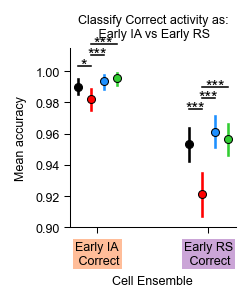

In [184]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct', 
    ensemble_subset = ['Early_IA_Correct', 'Early_RS_Correct'],ylim = [0.9, 1.015], figure_prefix = "6C", fig_folder=6)

#### Figure 6D: Time-based classification of Correct as Early IA vs Early RS, using Early RS Correct ensemble data


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\21_Jan_2026' already exists.
Saved 6_6D_Early RS Correct ensemble time-based classification of Early IA Correct v Early RS Correct_posthoc acc cohen D_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\6_6D_Early RS Correct ensemble time-based classification of Early IA Correct v Early RS Correct_posthoc_text_21_Jan_2026.txt


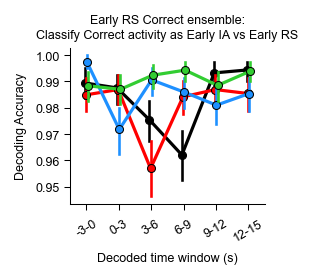

In [185]:
fig, ax,posthoc_df= plot_save_time_dep_decoding(time_decode_scores,decoding_col = "classes decoded", decoding_metric = 'accuracy', decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct',
    ensemble ='Early_RS_Correct', figsize = (1.75,1.75),figure_prefix = "6D", fig_num=6)

In [186]:

time_decode_scores

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,accuracy,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded,bin_name
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[0, 11]",0,11,-3.0s,0.99125,-0.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,-3.0s to -0.0s
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[12, 23]",12,23,0.0s,0.97875,3.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,0.0s to 3.0s
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[24, 35]",24,35,3.0s,0.99625,6.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,3.0s to 6.0s
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[36, 47]",36,47,6.0s,0.99875,9.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,6.0s to 9.0s
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[48, 59]",48,59,9.0s,0.99500,12.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,9.0s to 12.0s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1439995,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[12, 23]",12,23,0.0s,0.83500,3.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,0.0s to 3.0s
1439996,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[24, 35]",24,35,3.0s,0.92125,6.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,3.0s to 6.0s
1439997,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[36, 47]",36,47,6.0s,0.87000,9.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,6.0s to 9.0s
1439998,9999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[48, 59]",48,59,9.0s,0.86125,12.0s,12,0.25,2026-01-19 16:48:56.134116,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,9.0s to 12.0s


#### Supplementary Figure 2H: SVM accuracy classifying Correct as Early IA vs Early RS, using Early IA or RS Correct Ensemble data (showing WT CLNZ)

switching posthoc comparison to include WT CLNZ
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\21_Jan_2026' already exists.
Saved s_2_S2_H_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\s_2_S2_H_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc_text_21_Jan_2026.txt


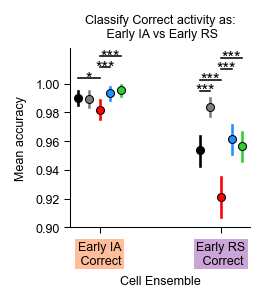

In [187]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct',
 ensemble_subset = ['Early_IA_Correct', 'Early_RS_Correct'], ylim = [0.9,1.025], figsize = supp_svm_panel_size,
  figure_prefix = "S2_H", fig_folder='s_2', plot_config = geno_order_w_WT_CLNZ_no_eb)

#### Figure 7C: SVM accuracy at classifying Early IA Correct vs. Late IA, using Early IA Correct/Late IA ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\21_Jan_2026' already exists.
Saved 7_7_C_SVM classifier accuracy Early_IA_Correct_v_Late_IA by ensemble_posthoc decode acc cohen D_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\7_7_C_SVM classifier accuracy Early_IA_Correct_v_Late_IA by ensemble_posthoc_text_21_Jan_2026.txt


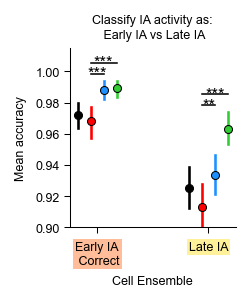

In [188]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Late_IA',
ensemble_subset = ['Early_IA_Correct', 'Late_IA'],figure_prefix = "7_C",fig_folder=7)

#### Figure 7G: SVM accuracy at classifying Early RS Correct vs. Late IA, using Early RS Correct/Late IA ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\21_Jan_2026' already exists.
Saved 7_7_G_SVM classifier accuracy Late_IA_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_21_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\7_7_G_SVM classifier accuracy Late_IA_v_Early_RS_Correct by ensemble_posthoc_text_21_Jan_2026.txt


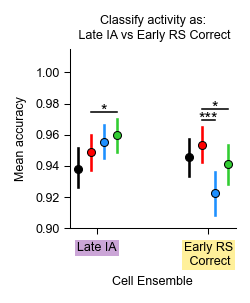

In [189]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Late_IA_v_Early_RS_Correct', 
    ensemble_subset = ['Early_RS_Correct', 'Late_IA'],figure_prefix = "7_G", fig_folder= 7)

## Summary Figure: All SVM Classifier Accuracy Plots

Combined view of all ensemble SVM accuracy comparisons from Figures 5, 6, 7, and Supplemental Figure 2.

{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Error_v_Early_RS_Error', 'ensemble_subset': ['Early_IA_Error', 'Early_RS_Error'], 'ylim': [0.8, 1.05], 'title': '5C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Correct_v_Early_RS_Correct', 'ensemble_subset': ['Early_IA_Correct', 'Early_RS_Correct'], 'ylim': [0.9, 1.015], 'title': '6C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Correct_v_Late_IA', 'ensemble_subset': ['Early_IA_Correct', 'Late_IA'], 'ylim': [0.9, 1.015], 'title': '7C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_compa

Text(0.5, 0.98, 'Summary: SVM Classifier Accuracy by Ensemble')

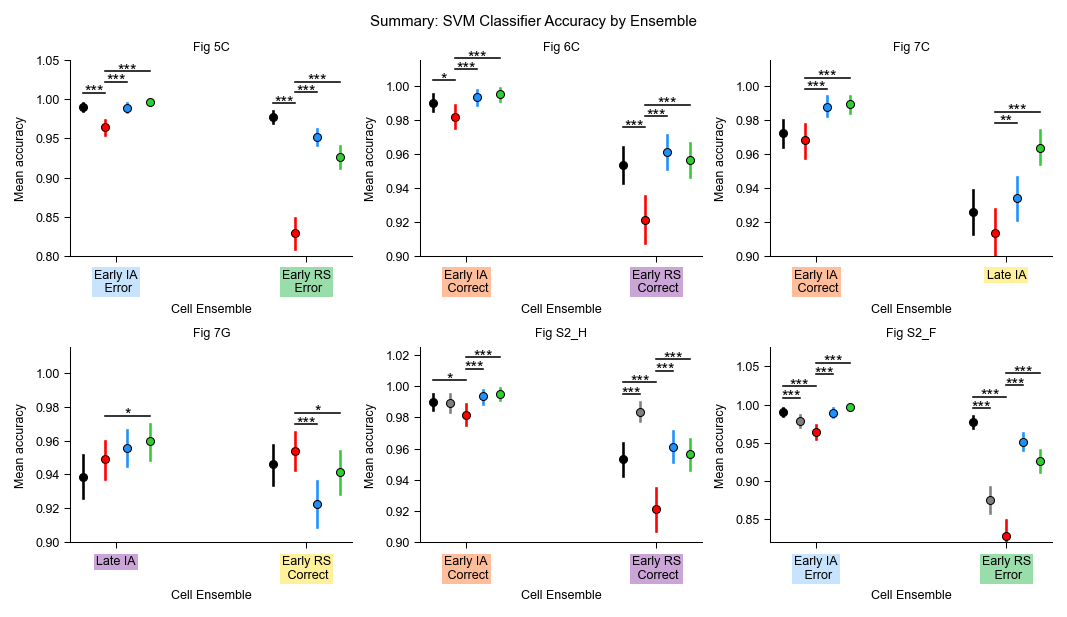

In [190]:
# Summary figure combining all SVM accuracy plots
fig, axes = plt.subplots(2, 3, figsize=(7, 4), layout="constrained")

# Define all plot configurations
plot_configs = [
    # Row 1
    {"ax": axes[0, 0], "decoder_comparison": "Early_IA_Error_v_Early_RS_Error",
     "ensemble_subset": ["Early_IA_Error", "Early_RS_Error"], "ylim": [0.80, 1.05],
     "title": "5C", "plot_config": geno_color_dict_no_errorbar},
    {"ax": axes[0, 1], "decoder_comparison": "Early_IA_Correct_v_Early_RS_Correct",
     "ensemble_subset": ["Early_IA_Correct", "Early_RS_Correct"], "ylim": [0.9, 1.015],
     "title": "6C", "plot_config": geno_color_dict_no_errorbar},
    {"ax": axes[0, 2], "decoder_comparison": "Early_IA_Correct_v_Late_IA",
     "ensemble_subset": ["Early_IA_Correct", "Late_IA"], "ylim": [0.90, 1.015],
     "title": "7C", "plot_config": geno_color_dict_no_errorbar},
     # Row 2
    {"ax": axes[1, 0], "decoder_comparison": "Late_IA_v_Early_RS_Correct",
     "ensemble_subset": ["Early_RS_Correct", "Late_IA"], "ylim": [0.90, 1.015],
     "title": "7G", "plot_config": geno_color_dict_no_errorbar},
     
     #supp 
     {"ax": axes[1, 1], "decoder_comparison": "Early_IA_Correct_v_Early_RS_Correct",
     "ensemble_subset": ["Early_IA_Correct", "Early_RS_Correct"], "ylim": [0.9, 1.025],
     "title": "S2_H", "plot_config": geno_order_w_WT_CLNZ_no_eb},
       {"ax": axes[1, 2], "decoder_comparison": "Early_IA_Error_v_Early_RS_Error",
     "ensemble_subset": ["Early_IA_Error", "Early_RS_Error"], "ylim": [0.82, 1.075],
     "title": "S2_F", "plot_config": geno_order_w_WT_CLNZ_no_eb},
]

# Generate each subplot
for config in plot_configs:
    print(config)
    plot_decode_accuracy_ensemble_subset(
        pop_mean_decoding,
        decoding_col="classes decoded",
        decoder_comparison=config["decoder_comparison"],
        ensemble_col="enriched_group",
        ax_plot=config["ax"],
        ensemble_subset=config["ensemble_subset"],
        ylim=config["ylim"],
        plot_config=config["plot_config"]
    )
    config["ax"].set_title(f"Fig {config['title']}", )

plt.suptitle("Summary: SVM Classifier Accuracy by Ensemble",)

# # Save the summary figure
# save_fig_in_main_fig_dir(fig, fig_name="Summary_SVM_classifier_accuracy_all_comparisons", 
#                         folder_key="1", filetypes_to_save=["png", "svg"])

## Summary Figure: All CCG Confusion Single Proportion Plots

Combined view of all CCG confusion proportion comparisons from Figures 3, 4, and Supplemental Figures.

In [191]:
# # Summary figure combining all CCG confusion single proportion plots
# fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# # Define all plot configurations
# plot_configs = [
#     # Row 1: Main figures (geno_order)
#     {"ax": axes[0, 0], "ensemble": "Early_RS_Correct",
#      "train": "train_Early_IA_Correct_x_Early_IA_Error",
#      "prediction_class": "Predict_Early_IA_Correct",
#      "genos_to_plot": geno_order, "ylim": [0, None], "title": "Fig 3C"},
#     {"ax": axes[0, 1], "ensemble": "Early_IA_Correct",
#      "train": "train_Early_IA_Correct_x_Early_RS_Correct",
#      "prediction_class": "Predict_Early_RS_Correct",
#      "genos_to_plot": geno_order, "ylim": [0, 110], "title": "Fig 4C"},
#     {"ax": axes[0, 2], "ensemble": "Early_RS_Error",
#      "train": "train_Early_IA_Correct_x_Early_RS_Correct",
#      "prediction_class": "Predict_Early_RS_Correct",
#      "genos_to_plot": geno_order, "ylim": [0, 110], "title": "Fig 4F"},
#     ]

# # Generate each subplot
# for config in plot_configs:
#     plot_ccg_confusion_single_proportion(
#         config["ax"],
#         input_df,
#         train=config["train"],
#         ens=config["ensemble"],
#         genos_to_plot=config["genos_to_plot"],
#         prediction_class=config["prediction_class"],
#         errorbar=("pi", 75),
#         ylim=config["ylim"]
#     )
#     config["ax"].set_title(f"{config['title']}", fontsize=10, fontweight="bold", loc="left")

# plt.suptitle("Summary: CCG Confusion Single Proportion", fontsize=12, fontweight="bold")
# plt.tight_layout()

# # Save the summary figure
# save_fig_in_main_fig_dir(fig, fig_name="Summary_CCG_confusion_single_proportion_all",
#                         folder_key="summary", filetypes_to_save=["png", "svg"])

## Compare Old vs New CCGP Results (Figures 3B & 4B)
Comparison of CCGP (Cross-Condition Generalization Performance) between:
- **Old**: `Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 31_May_2025.parquet`
- **New**: Most recent run from the decoding log

In [192]:
# Load old CCGP parquet file
old_CCG_filename = "Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 31_May_2025.parquet"
decode_out_distrib_old = pd.read_parquet(data_location / old_CCG_filename).rename(columns={"mean_acc": "accuracy"})

# Apply same column transformations as for the new data
decode_out_distrib_old['train_on'] = decode_out_distrib_old['class_0_train'].str.cat(decode_out_distrib_old['class_1_train'], sep="_").str.replace('_', ' ')
decode_out_distrib_old['test_on'] = decode_out_distrib_old['class_0_test'].str.cat(decode_out_distrib_old['class_1_test'], sep="_").str.replace('_', ' ')
decode_out_distrib_old['classes decoded'] = decode_out_distrib_old['train_on'].str.cat(decode_out_distrib_old['test_on'], sep=" v ")
decode_out_distrib_old['classes decoded'] = decode_out_distrib_old['classes decoded'].str.replace('_', ' ')
decode_out_distrib_old['total'] = decode_out_distrib_old['true_pos'] + decode_out_distrib_old['false_neg'] + decode_out_distrib_old['false_pos'] + decode_out_distrib_old['true_neg']

print(f"Loaded old CCGP data: {len(decode_out_distrib_old)} rows")
print(f"Current (new) CCGP data: {len(decode_out_distrib)} rows")
decode_out_distrib_old.head()

Loaded old CCGP data: 120000 rows
Current (new) CCGP data: 1200000 rows


,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,pseudopop_run_num,enriched_group,geno_day,...,date_run,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,classes decoded,total
0,0.691250,81.0,81.0,0.417031,0.274219,0.225781,0.082969,0,Early_IA_Correct,Het CLNZ,...,2025-05-31 16:06:16.834392,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Correct Early RS Correct,Early IA Error Early RS Error,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.772344,81.0,63.0,0.454219,0.318125,0.181875,0.045781,0,Early_IA_Correct,Het CLNZ,...,2025-05-31 16:06:16.895296,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Error Early RS Error,Early IA Correct Early RS Correct,Early IA Error Early RS Error v Early IA Corre...,1.0
2,0.569844,81.0,81.0,0.307500,0.262344,0.237656,0.192500,0,Early_IA_Correct,Het CLNZ,...,2025-05-31 16:06:16.942382,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Correct Early IA Error,Early RS Correct Early RS Error,Early IA Correct Early IA Error v Early RS Cor...,1.0
3,0.651250,81.0,57.0,0.381406,0.269844,0.230156,0.118594,0,Early_IA_Correct,Het CLNZ,...,2025-05-31 16:06:16.989851,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early RS Correct Early RS Error,Early IA Correct Early IA Error,Early RS Correct Early RS Error v Early IA Cor...,1.0
4,0.560938,29.0,29.0,0.276719,0.284219,0.215781,0.223281,0,Early_IA_Correct,Het VEH,...,2025-05-31 16:06:17.055557,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Correct Early RS Correct,Early IA Error Early RS Error,Early IA Correct Early RS Correct v Early IA E...,1.0


### Figure 3B Comparison - CCGP for models Trained on IA, Tested on RS
Side-by-side comparison of old (May 2025) vs new CCGP results

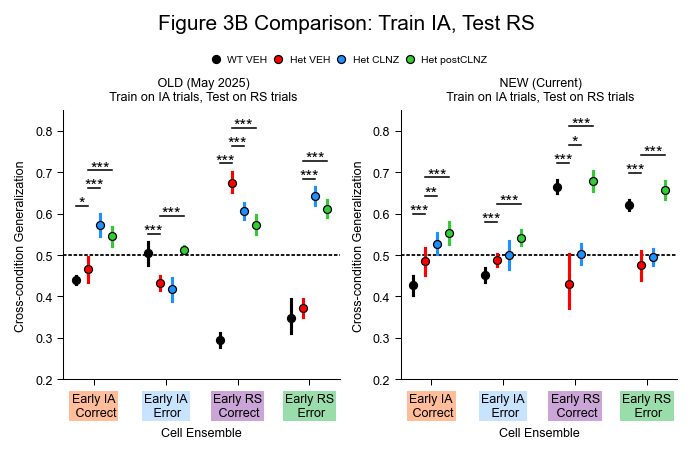

In [193]:
# Figure 3B comparison: Train on IA, Test on RS
train_data = 'train_Early_IA_Correct_Early_IA_Error'
decode_comp_3b = 'Early IA Correct Early IA Error v Early RS Correct Early RS Error'
ensembles_3b = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']

fig, axes = plt.subplots(1, 2, figsize=(4.5, 2.5), layout='constrained')

# Old data (left)
posthoc_df_old_3b = plot_cross_condition_generalization_performance(
    axes[0], decode_out_distrib_old,
    decoding_col='classes decoded', decode_comp=decode_comp_3b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85], verbose_titles=['OLD (May 2025)', verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[0], ensembles_3b, stage_palette_dict)
if axes[0].get_legend():
    axes[0].get_legend().remove()

# New data (right)
posthoc_df_new_3b = plot_cross_condition_generalization_performance(
    axes[1], decode_out_distrib,
    decoding_col='classes decoded', decode_comp=decode_comp_3b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85], verbose_titles=['NEW (Current)', verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[1], ensembles_3b, stage_palette_dict)

# Shared legend
hand, labs = axes[1].get_legend_handles_labels()
if axes[1].get_legend():
    axes[1].get_legend().remove()
fig.legend(hand, labs, bbox_to_anchor=(0.5, 1.0), loc='lower center', ncols=4, frameon=False, title=None)

fig.suptitle('Figure 3B Comparison: Train IA, Test RS', fontsize=10, y=1.15)
plt.show()

### Figure 4B Comparison - CCGP for models trained on Correct, Tested on Error
Side-by-side comparison of old (May 2025) vs new CCGP results

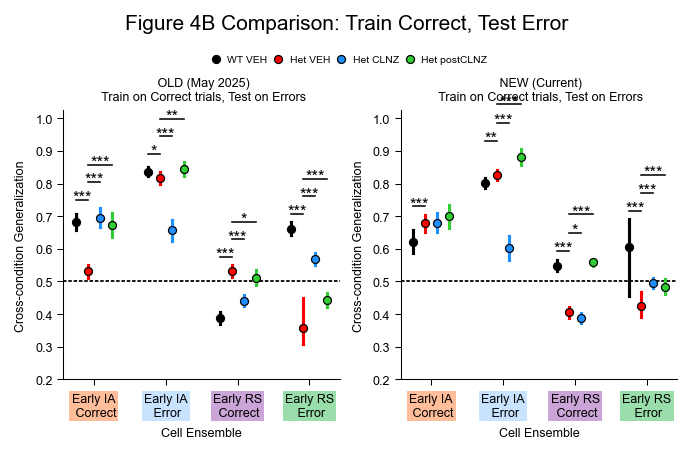

In [194]:
# Figure 4B comparison: Train on Correct (IA/RS), Test on Error (IA/RS)
train_data = 'train_Early_IA_Correct_Early_RS_Correct'
decode_comp_4b = 'Early IA Correct Early RS Correct v Early IA Error Early RS Error'
ensembles_4b = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']

fig, axes = plt.subplots(1, 2, figsize=(4.5, 2.5), layout='constrained')

# Old data (left)
posthoc_df_old_4b = plot_cross_condition_generalization_performance(
    axes[0], decode_out_distrib_old,
    decoding_col='classes decoded', decode_comp=decode_comp_4b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.025], verbose_titles=['OLD (May 2025)', verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[0], ensembles_4b, stage_palette_dict)
if axes[0].get_legend():
    axes[0].get_legend().remove()

# New data (right)
posthoc_df_new_4b = plot_cross_condition_generalization_performance(
    axes[1], decode_out_distrib,
    decoding_col='classes decoded', decode_comp=decode_comp_4b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.025], verbose_titles=['NEW (Current)', verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[1], ensembles_4b, stage_palette_dict)

# Shared legend
hand, labs = axes[1].get_legend_handles_labels()
if axes[1].get_legend():
    axes[1].get_legend().remove()
fig.legend(hand, labs, bbox_to_anchor=(0.5, 1.0), loc='lower center', ncols=4, frameon=False, title=None)

fig.suptitle('Figure 4B Comparison: Train Correct, Test Error', fontsize=10, y=1.15)
plt.show()

### Numeric Comparison Summary
Compare mean accuracy values between old and new CCGP results for each ensemble and decoding comparison

In [195]:
# Numeric comparison of old vs new CCGP accuracy - breakdown by geno_day and ensemble
def compare_ccgp_accuracy(df_old, df_new, decode_comp, ensembles, comparison_name):
    """Compare mean accuracy between old and new CCGP data, broken down by geno_day and ensemble."""
    results = []
    
    # Get all unique geno_days present in both datasets
    old_subset = df_old[df_old['classes decoded'] == decode_comp]
    new_subset = df_new[df_new['classes decoded'] == decode_comp]
    all_geno_days = sorted(set(old_subset['geno_day'].unique()) | set(new_subset['geno_day'].unique()))
    
    for geno_day in all_geno_days:
        for ens in ensembles:
            old_mask = (df_old['classes decoded'] == decode_comp) & (df_old['enriched_group'] == ens) & (df_old['geno_day'] == geno_day)
            new_mask = (df_new['classes decoded'] == decode_comp) & (df_new['enriched_group'] == ens) & (df_new['geno_day'] == geno_day)
            
            old_acc = df_old.loc[old_mask, 'accuracy']
            new_acc = df_new.loc[new_mask, 'accuracy']
            
            # Only add if there's data in at least one dataset
            if len(old_acc) > 0 or len(new_acc) > 0:
                old_mean = old_acc.mean() if len(old_acc) > 0 else np.nan
                new_mean = new_acc.mean() if len(new_acc) > 0 else np.nan
                diff = new_mean - old_mean if not (np.isnan(old_mean) or np.isnan(new_mean)) else np.nan
                
                results.append({
                    'Comparison': comparison_name,
                    'geno_day': geno_day,
                    'Ensemble': ens,
                    'Old Mean': old_mean,
                    'New Mean': new_mean,
                    'Difference': diff,
                    'Old N': len(old_acc),
                    'New N': len(new_acc)
                })
    return pd.DataFrame(results)

# Figure 3B comparison
comp_3b = compare_ccgp_accuracy(decode_out_distrib_old, decode_out_distrib, decode_comp_3b, ensembles_3b, 'Fig 3B (Train IA, Test RS)')

# Figure 4B comparison
comp_4b = compare_ccgp_accuracy(decode_out_distrib_old, decode_out_distrib, decode_comp_4b, ensembles_4b, 'Fig 4B (Train Correct, Test Error)')

# Combine and display
comparison_summary = pd.concat([comp_3b, comp_4b], ignore_index=True)
comparison_summary['Difference'] = comparison_summary['Difference'].apply(lambda x: f"{x:+.4f}" if pd.notna(x) else "N/A")
comparison_summary

,Comparison,geno_day,Ensemble,Old Mean,New Mean,Difference,Old N,New N
0,"Fig 3B (Train IA, Test RS)",Het CLNZ,Early_IA_Correct,0.571583,0.527072,-0.0445,1000,10000
1,"Fig 3B (Train IA, Test RS)",Het CLNZ,Early_IA_Error,0.417269,0.499627,+0.0824,1000,10000
2,"Fig 3B (Train IA, Test RS)",Het CLNZ,Early_RS_Correct,0.606837,0.502881,-0.1040,1000,10000
3,"Fig 3B (Train IA, Test RS)",Het CLNZ,Early_RS_Error,0.642864,0.496528,-0.1463,1000,10000
4,"Fig 3B (Train IA, Test RS)",Het VEH,Early_IA_Correct,0.465321,0.485059,+0.0197,1000,10000
5,"Fig 3B (Train IA, Test RS)",Het VEH,Early_IA_Error,0.432965,0.487817,+0.0549,1000,10000
6,"Fig 3B (Train IA, Test RS)",Het VEH,Early_RS_Correct,0.675171,0.431272,-0.2439,1000,10000
7,"Fig 3B (Train IA, Test RS)",Het VEH,Early_RS_Error,0.371494,0.474856,+0.1034,1000,10000
8,"Fig 3B (Train IA, Test RS)",Het postCLNZ,Early_IA_Correct,0.545007,0.553195,+0.0082,1000,10000
9,"Fig 3B (Train IA, Test RS)",Het postCLNZ,Early_IA_Error,0.513386,0.542132,+0.0287,1000,10000


### Investigate Potential Causes of Accuracy Differences
Two most likely causes for differences between old and new CCGP accuracy values:
1. **Different input trial timeseries data**: The parquet file used to build `class_matrix_store` may have changed (different preprocessing, different cells/trials included)
2. **Different decoding hyperparameters**: `num_resample`, `test_size`, `k_folds`, or `n_pseudopop_runs` may differ between runs

In [201]:
# Investigation 1: Check if the same geno_days (subjects) are present in both datasets
old_geno_days = set(decode_out_distrib_old['geno_day'].unique())
new_geno_days = set(decode_out_distrib['geno_day'].unique())

print("=== CAUSE 1: Different input trial timeseries data ===")
print(f"This would manifest as different subjects/geno_days being included")
print(f"Old dataset geno_days ({len(old_geno_days)}): {sorted(old_geno_days)}")
print(f"New dataset geno_days ({len(new_geno_days)}): {sorted(new_geno_days)}")
print(f"Only in OLD: {sorted(old_geno_days - new_geno_days)}")
print(f"Only in NEW: {sorted(new_geno_days - old_geno_days)}")
print(f"In BOTH: {len(old_geno_days & new_geno_days)} geno_days")

# Check total row counts per geno_day and enriched_group
print("--- Row counts per geno_day (summed across all comparisons) ---")
old_counts = decode_out_distrib_old.groupby('geno_day').size().rename('old_n_rows')
new_counts = decode_out_distrib.groupby('geno_day').size().rename('new_n_rows')
count_comparison = pd.concat([old_counts, new_counts], axis=1).fillna(0).astype(int)
count_comparison['diff'] = count_comparison['new_n_rows'] - count_comparison['old_n_rows']
print(count_comparison)

# Investigation 2: Check decoding run metadata if available
print("=== CAUSE 2: Different decoding hyperparameters ===")
print("Check the decoding run log for parameter differences:")
print("Key parameters: num_resample, test_size, k_folds, n_pseudopop_runs (n_iterations)")

# Try to get run info from the log
try:
    run_log_path = results_location / "decode_run_log.csv"
    if run_log_path.exists():
        run_log = pd.read_csv(run_log_path)
        ood_runs = run_log[run_log['decoding_type'] == 'out_of_distribution'].sort_values('run_end_time')
        print(f"Found {len(ood_runs)} out_of_distribution runs in log:")
        print(ood_runs[['run_date', 'run_end_time', 'run_dataset_used', 'n_iterations']].tail(5))
    else:
        print(f"Run log not found at {run_log_path}")
except Exception as e:
    print(f"Could not read run log: {e}")

# Compare column structure to detect any schema differences
print("=== Additional check: Column differences ===")
old_cols = set(decode_out_distrib_old.columns)
new_cols = set(decode_out_distrib.columns)
if old_cols != new_cols:
    print(f"Columns only in OLD: {old_cols - new_cols}")
    print(f"Columns only in NEW: {new_cols - old_cols}")
else:
    print("Both dataframes have identical column names")


=== CAUSE 1: Different input trial timeseries data ===
This would manifest as different subjects/geno_days being included
Old dataset geno_days (5): ['Het CLNZ', 'Het VEH', 'Het postCLNZ', 'WT CLNZ', 'WT VEH']
New dataset geno_days (5): ['Het CLNZ', 'Het VEH', 'Het postCLNZ', 'WT CLNZ', 'WT VEH']
Only in OLD: []
Only in NEW: []
In BOTH: 5 geno_days
--- Row counts per geno_day (summed across all comparisons) ---
              old_n_rows  new_n_rows    diff
geno_day                                    
Het CLNZ           24000      240000  216000
Het VEH            24000      240000  216000
Het postCLNZ       24000      240000  216000
WT CLNZ            24000      240000  216000
WT VEH             24000      240000  216000
=== CAUSE 2: Different decoding hyperparameters ===
Check the decoding run log for parameter differences:
Key parameters: num_resample, test_size, k_folds, n_pseudopop_runs (n_iterations)
Run log not found at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC

In [207]:
newest_raster = 'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet'
old_raster = 'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet'

### Compare Input Trial Timeseries Data
Direct comparison of the underlying activity data used for decoding:
- **Old**: `Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet`
- **New**: `python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet`

Compare ensemble activity for each task stage to identify where the input data differs.

In [213]:
# Load both input timeseries parquet files
newest_raster_path = data_location / "python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet"
old_raster_path = data_location / "Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"

df_new = pd.read_parquet(newest_raster_path)
df_old = pd.read_parquet(old_raster_path)

print(f"Old dataset shape: {df_old.shape}")
print(f"New dataset shape: {df_new.shape}")

# Identify numeric activity columns (timeseries columns)
numeric_cols_old = [c for c in df_old.columns if ' to ' in c]
numeric_cols_new = [c for c in df_new.columns if ' to ' in c]

# Task stage column
stage_col = 'task_phase_vec'

# Ensemble columns (binary vectors indicating enrichment)
ensemble_cols = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']

# Figure 3B: Train IA, Test RS
train_stages_3b = ['Early_IA_Correct', 'Early_IA_Error']
test_stages_3b = ['Early_RS_Correct', 'Early_RS_Error']

# Figure 4B: Train Correct, Test Error  
train_stages_4b = ['Early_IA_Correct', 'Early_RS_Correct']
test_stages_4b = ['Early_IA_Error', 'Early_RS_Error']

def get_ensemble_activity_in_stages(df, numeric_cols, stage_col, ensemble_cols, activity_stages):
    """
    Get activity of cells enriched in each ensemble when in trials from activity_stages.
    ensemble_cols are binary columns indicating if a cell is enriched for that ensemble.
    """
    results = []
    for ens_col in ensemble_cols:
        # Filter to cells enriched in this ensemble
        ens_mask = df[ens_col] == 1
        
        for act_stage in activity_stages:
            # Filter to trials from this activity stage
            stage_mask = df[stage_col] == act_stage
            subset = df[ens_mask & stage_mask]
            
            if len(subset) > 0:
                mean_act = subset[numeric_cols].mean().mean()
                results.append({
                    'ensemble': ens_col,
                    'activity_stage': act_stage,
                    'mean_activity': mean_act,
                    'n_rows': len(subset)
                })
    return pd.DataFrame(results)

# Compare for Figure 3B stages
print("=== Figure 3B: Train on IA, Test on RS ===")
print("Ensemble activity in TRAIN stages (IA):")
ens_3b_train_old = get_ensemble_activity_in_stages(df_old, numeric_cols_old, stage_col, ensemble_cols, train_stages_3b)
ens_3b_train_new = get_ensemble_activity_in_stages(df_new, numeric_cols_new, stage_col, ensemble_cols, train_stages_3b)
comp_3b_train = ens_3b_train_old.merge(ens_3b_train_new, on=['ensemble', 'activity_stage'], suffixes=('_old', '_new'))
comp_3b_train['mean_diff'] = comp_3b_train['mean_activity_new'] - comp_3b_train['mean_activity_old']
print(comp_3b_train)

print()
print("Ensemble activity in TEST stages (RS):")
ens_3b_test_old = get_ensemble_activity_in_stages(df_old, numeric_cols_old, stage_col, ensemble_cols, test_stages_3b)
ens_3b_test_new = get_ensemble_activity_in_stages(df_new, numeric_cols_new, stage_col, ensemble_cols, test_stages_3b)
comp_3b_test = ens_3b_test_old.merge(ens_3b_test_new, on=['ensemble', 'activity_stage'], suffixes=('_old', '_new'))
comp_3b_test['mean_diff'] = comp_3b_test['mean_activity_new'] - comp_3b_test['mean_activity_old']
print(comp_3b_test)

print()
print("=== Figure 4B: Train on Correct, Test on Error ===")
print("Ensemble activity in TRAIN stages (Correct):")
ens_4b_train_old = get_ensemble_activity_in_stages(df_old, numeric_cols_old, stage_col, ensemble_cols, train_stages_4b)
ens_4b_train_new = get_ensemble_activity_in_stages(df_new, numeric_cols_new, stage_col, ensemble_cols, train_stages_4b)
comp_4b_train = ens_4b_train_old.merge(ens_4b_train_new, on=['ensemble', 'activity_stage'], suffixes=('_old', '_new'))
comp_4b_train['mean_diff'] = comp_4b_train['mean_activity_new'] - comp_4b_train['mean_activity_old']
print(comp_4b_train)

print()
print("Ensemble activity in TEST stages (Error):")
ens_4b_test_old = get_ensemble_activity_in_stages(df_old, numeric_cols_old, stage_col, ensemble_cols, test_stages_4b)
ens_4b_test_new = get_ensemble_activity_in_stages(df_new, numeric_cols_new, stage_col, ensemble_cols, test_stages_4b)
comp_4b_test = ens_4b_test_old.merge(ens_4b_test_new, on=['ensemble', 'activity_stage'], suffixes=('_old', '_new'))
comp_4b_test['mean_diff'] = comp_4b_test['mean_activity_new'] - comp_4b_test['mean_activity_old']
print(comp_4b_test)

Old dataset shape: (93253, 93)
New dataset shape: (92731, 96)
=== Figure 3B: Train on IA, Test on RS ===
Ensemble activity in TRAIN stages (IA):
           ensemble    activity_stage  mean_activity_old  n_rows_old  \
0  Early_IA_Correct  Early_IA_Correct           0.142429        2296   
1  Early_IA_Correct    Early_IA_Error           0.060433         869   
2    Early_IA_Error  Early_IA_Correct           0.053015        1482   
3    Early_IA_Error    Early_IA_Error           0.176586         921   
4  Early_RS_Correct  Early_IA_Correct           0.075182        1159   
5  Early_RS_Correct    Early_IA_Error           0.051730         456   
6    Early_RS_Error  Early_IA_Correct           0.058362        1246   
7    Early_RS_Error    Early_IA_Error           0.055052         491   

   mean_activity_new  n_rows_new  mean_diff  
0           0.098243        2765  -0.044187  
1           0.059313        1018  -0.001121  
2           0.051575        1391  -0.001440  
3           0.127402  

### Compare Timeseries Values for Matching Cells
Check if the same unique cells have different activity timeseries values between the two dataframes.

In [220]:
# Different ID column names between dataframes
id_col_old = 'unique_ID'
id_col_new = 'neuron_id'
trial_col = 'trial_num'
stage_col = 'task_phase_vec'

print(f"Old ID column: {id_col_old}, New ID column: {id_col_new}")

# Rename new df's ID column to match old for merging
df_new_renamed = df_new.rename(columns={id_col_new: id_col_old})

merge_cols = [id_col_old, trial_col, stage_col]
print(f"Matching on columns: {merge_cols}")

# Merge on identifiers to find matching rows
merged = df_old[merge_cols + numeric_cols_old].merge(
    df_new_renamed[merge_cols + numeric_cols_new],
    on=merge_cols,
    suffixes=('_old', '_new'),
    how='inner'
)
print(f"Matched rows: {len(merged)} (out of {len(df_old)} old, {len(df_new)} new)")

# Compare timeseries values for first numeric column as a sample
sample_col = numeric_cols_old[0]
old_vals = merged[f"{sample_col}_old"]
new_vals = merged[f"{sample_col}_new"]

# Check if values are identical
identical = (old_vals == new_vals).all()
print(f"Values identical for '{sample_col}': {identical}")

if not identical:
    # Check correlation
    corr = old_vals.corr(new_vals)
    print(f"Correlation between old and new: {corr:.4f}")
    
    # Check if it's a simple scaling
    ratio = (new_vals / old_vals.replace(0, np.nan)).dropna()
    print(f"Mean ratio (new/old): {ratio.mean():.4f}, Std: {ratio.std():.4f}")
    
    # Show sample of differences
    diff = new_vals - old_vals
    print(f"Difference stats:")
    print(f"  Mean diff: {diff.mean():.6f}")
    print(f"  Std diff: {diff.std():.6f}")
    print(f"  Min diff: {diff.min():.6f}")
    print(f"  Max diff: {diff.max():.6f}")
    
    # Sample a few rows to inspect
    print(f"Sample of matched rows (first 5):")
    sample_df = merged[[f"{sample_col}_old", f"{sample_col}_new"]].head()
    sample_df['diff'] = sample_df[f"{sample_col}_new"] - sample_df[f"{sample_col}_old"]
    print(sample_df)

Old ID column: unique_ID, New ID column: neuron_id
Matching on columns: ['unique_ID', 'trial_num', 'task_phase_vec']
Matched rows: 92731 (out of 93253 old, 92731 new)
Values identical for '-3.0s to -2.75s': True


In [218]:
df_new.neuron_id.unique

<bound method Series.unique of 0         10_3_HET_RS1-1
1        10_3_HET_RS1-10
3       10_3_HET_RS1-101
5       10_3_HET_RS1-104
8       10_3_HET_RS1-107
              ...       
3947      9_3_HET_RS3-95
3948      9_3_HET_RS3-96
3949      9_3_HET_RS3-97
3950      9_3_HET_RS3-98
3951      9_3_HET_RS3-99
Name: neuron_id, Length: 92731, dtype: object>

In [215]:
# Find rows in old that are not in new
id_col_old = 'unique_ID'
id_col_new = 'neuron_id'
trial_col = 'trial_num'
stage_col = 'task_phase_vec'

# Create merge keys
df_old['merge_key'] = df_old[id_col_old].astype(str) + '_' + df_old[trial_col].astype(str) + '_' + df_old[stage_col].astype(str)
df_new['merge_key'] = df_new[id_col_new].astype(str) + '_' + df_new[trial_col].astype(str) + '_' + df_new[stage_col].astype(str)

# Find keys only in old
old_keys = set(df_old['merge_key'])
new_keys = set(df_new['merge_key'])
missing_keys = old_keys - new_keys

print(f"Rows only in OLD: {len(missing_keys)}")

# Breakdown by task stage
print()
print("Missing rows by task stage:")
print(missing_rows[stage_col].value_counts())

# Get the missing rows
missing_rows = df_old[df_old['merge_key'].isin(missing_keys)]

# Breakdown by task stage
print()
print("Missing rows by task stage:")
print(missing_rows[stage_col].value_counts())

# Breakdown by geno_day
print()
print("Missing rows by geno_day:")
print(missing_rows['geno_day'].value_counts())

# Breakdown by unique cell
print()
print(f"Number of unique cells affected: {missing_rows[id_col_old].nunique()}")
print()
print("Missing rows by cell (top 10):")
print(missing_rows[id_col_old].value_counts().head(10))

# Check if entire cells are missing or just specific trials
cells_in_old = set(df_old[id_col_old].unique())
cells_in_new = set(df_new[id_col_new].unique())
cells_only_in_old = cells_in_old - cells_in_new
print()
print(f"Cells completely missing from new: {len(cells_only_in_old)}")
if len(cells_only_in_old) > 0:
    print(f"Missing cell IDs: {list(cells_only_in_old)[:10]}...")

Using ID column: unique_ID
Matching on columns: ['unique_ID', 'trial_num', 'task_phase_vec']


KeyError: "['unique_ID'] not in index"

### Investigate Missing Rows
Identify the 522 rows present in old but not in new dataset.

In [ ]:
# Find rows in old that are not in new
id_col_old = 'unique_ID'
id_col_new = 'neuron_id'
trial_col = 'trial_num'
stage_col = 'task_phase_vec'

# Create merge keys
df_old['merge_key'] = df_old[id_col_old].astype(str) + '_' + df_old[trial_col].astype(str) + '_' + df_old[stage_col].astype(str)
df_new['merge_key'] = df_new[id_col_new].astype(str) + '_' + df_new[trial_col].astype(str) + '_' + df_new[stage_col].astype(str)

# Find keys only in old
old_keys = set(df_old['merge_key'])
new_keys = set(df_new['merge_key'])
missing_keys = old_keys - new_keys

print(f"Rows only in OLD: {len(missing_keys)}")

# Get the missing rows
missing_rows = df_old[df_old['merge_key'].isin(missing_keys)]

# Breakdown by task stage
print(f"
Missing rows by task stage:")
print(missing_rows[stage_col].value_counts())

# Breakdown by geno_day
print(f"
Missing rows by geno_day:")
print(missing_rows['geno_day'].value_counts())

# Breakdown by unique cell
print(f"
Number of unique cells affected: {missing_rows[id_col_old].nunique()}")
print(f"
Missing rows by cell (top 10):")
print(missing_rows[id_col_old].value_counts().head(10))

# Check if entire cells are missing or just specific trials
cells_in_old = set(df_old[id_col_old].unique())
cells_in_new = set(df_new[id_col_new].unique())
cells_only_in_old = cells_in_old - cells_in_new
print(f"
Cells completely missing from new: {len(cells_only_in_old)}")
if len(cells_only_in_old) > 0:
    print(f"Missing cell IDs: {list(cells_only_in_old)[:10]}...")

### Activity of Missing 27 Cells in Old Dataset
Check if these cells have unusual activity patterns that might explain their exclusion.

In [ ]:
# Get the 27 missing cell IDs
missing_cell_ids = list(cells_only_in_old)

# Get activity of missing cells in old dataset
missing_cells_df = df_old[df_old[id_col_old].isin(missing_cell_ids)]

print(f"Missing cells: {len(missing_cell_ids)}")
print(f"Total rows from missing cells: {len(missing_cells_df)}")

# Compare mean activity of missing cells vs retained cells
retained_cells_df = df_old[~df_old[id_col_old].isin(missing_cell_ids)]

missing_mean = missing_cells_df[numeric_cols_old].mean().mean()
retained_mean = retained_cells_df[numeric_cols_old].mean().mean()

print()
print(f"Mean activity of MISSING cells: {missing_mean:.6f}")
print(f"Mean activity of RETAINED cells: {retained_mean:.6f}")
print(f"Ratio (missing/retained): {missing_mean/retained_mean:.2f}")

# Check enrichment status of missing cells
print()
print("Enrichment status of missing cells:")
for ens_col in ensemble_cols:
    n_enriched = missing_cells_df.groupby(id_col_old)[ens_col].max().sum()
    print(f"  {ens_col}: {int(n_enriched)} cells enriched")

# Activity breakdown by task stage for missing cells
print()
print("Mean activity of missing cells by task stage:")
missing_by_stage = missing_cells_df.groupby(stage_col)[numeric_cols_old].mean().mean(axis=1)
print(missing_by_stage)

# Show individual cell activity summary
print()
print("Per-cell mean activity (missing cells):")
cell_means = missing_cells_df.groupby(id_col_old)[numeric_cols_old].mean().mean(axis=1).sort_values()
print(cell_means)

### Compare Enrichment Assignments Between Old and New
Check if the same cells have different ensemble enrichment status between datasets.

In [235]:
# Get enrichment status per cell (max across trials since it's constant per cell)
id_col_old = 'unique_ID'
id_col_new = 'neuron_id'

# Get unique cell enrichment from old
old_enrich = df_old.groupby(id_col_old)[ensemble_cols].max().reset_index()
old_enrich = old_enrich.rename(columns={col: f"{col}_old" for col in ensemble_cols})

# Get unique cell enrichment from new
new_enrich = df_new.groupby(id_col_new)[ensemble_cols].max().reset_index()
new_enrich = new_enrich.rename(columns={id_col_new: id_col_old})
new_enrich = new_enrich.rename(columns={col: f"{col}_new" for col in ensemble_cols})

# Merge on cell ID
enrich_comp = old_enrich.merge(new_enrich, on=id_col_old, how='inner')
print(f"Cells in both datasets: {len(enrich_comp)}")

# Check for differences in each ensemble
print()
print("=== Enrichment assignment differences ===")
for ens in ensemble_cols:
    old_col = f"{ens}_old"
    new_col = f"{ens}_new"
    
    # Count cells with different enrichment
    diff_mask = enrich_comp[old_col] != enrich_comp[new_col]
    n_diff = diff_mask.sum()
    
    # Breakdown: gained vs lost enrichment
    gained = ((enrich_comp[old_col] == 0) & (enrich_comp[new_col] == 1)).sum()
    lost = ((enrich_comp[old_col] == 1) & (enrich_comp[new_col] == 0)).sum()
    
    # Total enriched in each
    n_old = enrich_comp[old_col].sum()
    n_new = enrich_comp[new_col].sum()
    
    print(f"{ens}:")
    print(f"  Old: {int(n_old)} enriched, New: {int(n_new)} enriched")
    print(f"  Differences: {n_diff} cells (gained: {gained}, lost: {lost})")

# Overall summary
print()
print("=== Overall enrichment counts ===")
for ens in ensemble_cols:
    old_total = df_old.groupby(id_col_old)[ens].max().sum()
    new_total = df_new.groupby(id_col_new)[ens].max().sum()
    print(f"{ens}: Old={int(old_total)}, New={int(new_total)}, Diff={int(new_total - old_total)}")

# Show cells that changed enrichment status
print()
print("=== Cells with changed enrichment (first 20) ===")
any_diff = False
for ens in ensemble_cols:
    old_col = f"{ens}_old"
    new_col = f"{ens}_new"
    diff_mask = enrich_comp[old_col] != enrich_comp[new_col]
    if diff_mask.any():
        any_diff = True
        changed = enrich_comp[diff_mask][[id_col_old, old_col, new_col]].head(5)
        print(f"{ens} changes:")
        print(changed.to_string(index=False))
        print()

if not any_diff:
    print("No cells changed enrichment status between datasets")

Cells in both datasets: 4749

=== Enrichment assignment differences ===
Early_IA_Correct:
  Old: 626 enriched, New: 748 enriched
  Differences: 791 cells (gained: 422, lost: 295)
Early_IA_Error:
  Old: 478 enriched, New: 451 enriched
  Differences: 1386 cells (gained: 202, lost: 225)
Early_RS_Correct:
  Old: 320 enriched, New: 351 enriched
  Differences: 454 cells (gained: 207, lost: 173)
Early_RS_Error:
  Old: 345 enriched, New: 376 enriched
  Differences: 452 cells (gained: 207, lost: 171)

=== Overall enrichment counts ===
Early_IA_Correct: Old=628, New=748, Diff=120
Early_IA_Error: Old=479, New=451, Diff=-28
Early_RS_Correct: Old=320, New=351, Diff=31
Early_RS_Error: Old=345, New=376, Diff=31

=== Cells with changed enrichment (first 20) ===
Early_IA_Correct changes:
       unique_ID  Early_IA_Correct_old  Early_IA_Correct_new
10_3_HET_RS1-104                   0.0                   1.0
10_3_HET_RS1-122                   0.0                   1.0
10_3_HET_RS1-126                   